In [2]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer
import os
import sys
# import json
import yaml
from datasets import load_dataset
import numpy as np
import matplotlib.pyplot as plt
import warnings

curr_dir = os.path.dirname(os.path.abspath(__file__)) if '__file__' in globals() else os.getcwd()
print(f"Current directory: {curr_dir}")
PROJECT_DIR = os.path.abspath(os.path.join(curr_dir, '..', '..', '..'))
print(f"Project directory: {PROJECT_DIR}")
Unlearn_Simple_DIR = os.path.join(PROJECT_DIR, 'Unlearn-Simple')
print(f"Unlearn_Simple_DIR: {Unlearn_Simple_DIR}")
TOFU_DIR = os.path.join(Unlearn_Simple_DIR, 'TOFU')
print(f"TOFU_DIR: {TOFU_DIR}")
WMDP_DIR = os.path.join(Unlearn_Simple_DIR, 'WMDP')
print(f"WMDP_DIR: {WMDP_DIR}")

# clean GPU mem
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()
    
    
# Import evaluation functions
sys.path.append(Unlearn_Simple_DIR)
sys.path.append(TOFU_DIR)
sys.path.append(WMDP_DIR)
sys.path.append(os.path.join(WMDP_DIR, 'src'))
sys.path.append(os.path.join(TOFU_DIR, 'evals'))

MUSE_DIR = os.path.join(Unlearn_Simple_DIR, 'MUSE')
MUSE_SRC_DIR = os.path.join(MUSE_DIR, 'src')
sys.path.append(MUSE_SRC_DIR)

# Import ILL evaluation utilities
import MUSE.src.eval_with_ILL as eval_with_ILL

# Add project source directory
sys.path.append(PROJECT_DIR)
import src.utils as project_utils
from src.input_loss_landscape.utils import *


# Perform Input Loss Landscape (ILL) evaluation on TOFU data
from src.input_loss_landscape.utils import new_ILL_eval

Current directory: /home/liranc6/W25/adversarial-attacks-on-deep-learning/project/Unlearn-Simple/WMDP/notebooks
Project directory: /home/liranc6/W25/adversarial-attacks-on-deep-learning/project
Unlearn_Simple_DIR: /home/liranc6/W25/adversarial-attacks-on-deep-learning/project/Unlearn-Simple
TOFU_DIR: /home/liranc6/W25/adversarial-attacks-on-deep-learning/project/Unlearn-Simple/TOFU
WMDP_DIR: /home/liranc6/W25/adversarial-attacks-on-deep-learning/project/Unlearn-Simple/WMDP


In [3]:
# plt.rcParams['figure.figsize'] = [16, 10]  # or [20, 12] for even larger
# plt.rcParams['figure.dpi'] = 100

In [4]:
# # Load WMDP configs
# # WMDP uses JSON config files instead of YAML
# config_path = os.path.join(WMDP_DIR, 'configs', 'unlearn', 'wmdp', 'SimNPO.json')

# with open(config_path, 'r') as f:
#     wmdp_config = json.load(f)

# # print("WMDP Configuration:")
# print(json.dumps(wmdp_config, indent=2))

# # Extract relevant information
# model_name = wmdp_config.get('overall', {}).get('model_name', "HuggingFaceH4/zephyr-7b-beta")
# dataset_info = wmdp_config.get('dataset', {})
# forget_dataset_name = dataset_info.get('forget_dataset_name', "WMDPBio")
# retain_dataset_name = dataset_info.get('retain_dataset_name', "WMDPBio")
# forget_ratio = dataset_info.get('forget_ratio', 1.0)

# print(f"Model: {model_name}")
# print(f"Forget dataset: {forget_dataset_name}")
# print(f"Retain dataset: {retain_dataset_name}")
# print(f"Forget ratio: {forget_ratio}")

In [5]:
# Load forget dataset (biological weapon-related knowledge)
forget_data = load_dataset("cais/wmdp-bio-forget-corpus", cache_dir="./.cache", split='train')

# Load retain dataset (general/auxiliary knowledge)
retain_data = load_dataset("cais/wmdp-corpora", "bio-retain-corpus", cache_dir="./.cache")['train']

# Load holdout dataset (evaluation benchmark)
raw_holdout_data = load_dataset("cais/wmdp", "wmdp-bio", cache_dir="./.cache", split='test')

print(f"Loaded forget dataset: {len(forget_data)} samples")
print(f"Loaded retain dataset: {len(retain_data)} samples")
print(f"Loaded holdout dataset: {len(raw_holdout_data)} samples")

Generating train split:   0%|          | 0/24453 [00:00<?, ? examples/s]

Generating train split:   0%|          | 0/60887 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1273 [00:00<?, ? examples/s]

Loaded forget dataset: 24453 samples
Loaded retain dataset: 60887 samples
Loaded holdout dataset: 1273 samples


In [6]:
# Examine dataset structure
print("\nDataset structures:")
if len(forget_data) > 0:
    print("\nForget data features:", forget_data.features)
    # print("\nFirst forget example:")
    # print(forget_data[0])


if len(retain_data) > 0:
    print("\nRetain data features:", retain_data.features)
    # print("\nFirst retain example:")
    # print(retain_data[0])

if len(raw_holdout_data) > 0:
    print("\nHoldout data features:", raw_holdout_data.features)
    # print("\nFirst holdout example:")
    # print(holdout_data[0])
    
# Limit dataset size for computational efficiency
subset_len = 30
forget_data = forget_data.select(range(min(subset_len, len(forget_data))))
retain_data = retain_data.select(range(min(subset_len, len(retain_data))))
holdout_data = raw_holdout_data.select(range(min(subset_len, len(raw_holdout_data))))

print(f"\nUsing {len(forget_data)} forget, {len(retain_data)} retain, {len(holdout_data)} holdout examples")


Dataset structures:

Forget data features: {'title': Value('string'), 'abstract': Value('string'), 'text': Value('string'), 'doi': Value('string')}

Retain data features: {'text': Value('string')}

Holdout data features: {'answer': Value('int64'), 'question': Value('string'), 'choices': List(Value('string'))}

Using 30 forget, 30 retain, 30 holdout examples


In [7]:
def convert_holdout(example):
    return {'question': example['question'], 'answer': example['choices'][example['answer']]}

holdout_data = holdout_data.map(convert_holdout, remove_columns=['choices'])  # Drop 'choices' and keep only 'question' and 'answer'

Map:   0%|          | 0/30 [00:00<?, ? examples/s]

In [8]:
cfg_forget_file = os.path.join(TOFU_DIR, 'config', 'model_config.yaml')

print(f"{cfg_forget_file=}")
# Load model configurations
with open(cfg_forget_file, 'r') as f:
    cfg_forget = yaml.safe_load(f)

print(cfg_forget)


cfg_forget_file='/home/liranc6/W25/adversarial-attacks-on-deep-learning/project/Unlearn-Simple/TOFU/config/model_config.yaml'
{'llama2-7b': {'hf_key': 'NousResearch/Llama-2-7b-chat-hf', 'question_start_tag': '[INST] ', 'question_end_tag': ' [/INST]', 'answer_tag': '', 'flash_attention2': 'true', 'gradient_checkpointing': 'true', 'ft_model_path': 'locuslab/tofu_ft_llama2-7b'}, 'phi': {'hf_key': 'microsoft/phi-1_5', 'question_start_tag': 'Question: ', 'question_end_tag': '\n', 'answer_tag': 'Answer: ', 'flash_attention2': 'false', 'gradient_checkpointing': 'false', 'ft_model_path': 'paper_models/final_ft_noLORA_5_epochs_inst_lr2e-05_phi_full/checkpoint-625'}, 'stablelm': {'hf_key': 'stabilityai/stablelm-3b-4e1t', 'question_start_tag': 'Question: ', 'question_end_tag': '\n', 'answer_tag': 'Answer: ', 'flash_attention2': 'false', 'gradient_checkpointing': 'false', 'ft_model_path': 'paper_models/final_ft_noLORA_5_epochs_inst_lr1e-05_stablelm/checkpoint-625'}, 'pythia-1.4': {'hf_key': 'Eleut

In [9]:
# Load forget config
cfg_forget_file = os.path.join(TOFU_DIR, 'config', 'forget.yaml')
print(f"{cfg_forget_file=}")
with open(cfg_forget_file, 'r') as f:
    cfg_forget = yaml.safe_load(f)

model_family = cfg_forget['model_family']

# Load model config for prompt tags
model_config_file = os.path.join(TOFU_DIR, 'config', 'model_config.yaml')
with open(model_config_file, 'r') as f:
    model_configs = yaml.safe_load(f)

model_cfg = model_configs[model_family]
question_start_tag = model_cfg['question_start_tag']
question_end_tag = model_cfg['question_end_tag']
answer_tag = model_cfg['answer_tag']
start_of_sequence_token = "<s>"

model_configs = {
    'question_start_tag': "### Question: ",
    'question_end_tag': "\n",
    'answer_tag': "### Answer: ",
}

cfg_forget_file='/home/liranc6/W25/adversarial-attacks-on-deep-learning/project/Unlearn-Simple/TOFU/config/forget.yaml'


In [16]:
# Model and tokenizer loading (no chat_template)
model_name = f"LLM-GAT/llama-3-8b-instruct-elm-checkpoint-8" 
# LLM-GAT/llama-3-8b-instruct-{elm, graddiff, tar, pbj, rmu-lat, rmu, rr, repnoise}-checkpoint-8
tokenizer_name = model_name #"meta-llama/Meta-Llama-3-8B" #"meta-llama/Llama-3.1-8B"

# warnings.warn("\033[93m[WARNING] The tokenizer ('meta-llama/Llama-3.1-8B') does not exactly match the model ('LLM-GAT/llama-3-8b-instruct-graddiff-checkpoint-8'). This may cause unexpected behavior or errors.\033[0m")


print(f"Loading model: {model_name}")
print(f"Downloading and loading model: {model_name}")
tokenizer = AutoTokenizer.from_pretrained(
    tokenizer_name,
    # local_files_only=False       # ← do not rely on local cache
)

model = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype=torch.float16,
    device_map="auto",
    # local_files_only=False
)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
    model.config.pad_token_id = tokenizer.eos_token_id

model.resize_token_embeddings(len(tokenizer))
# model.config.pad_token_id = tokenizer.eos_token_id
print("Model and tokenizer loaded successfully!")

print(f"Model device: {next(model.parameters()).device}")

# Prompt formatting function (matches TOFU training/forgetting)
def build_prompt(question, answer=None):
    prompt = f"{start_of_sequence_token}{question_start_tag}{question}{question_end_tag}"
    if answer is not None:
        prompt += f"{answer_tag}{answer}"
    return prompt

Loading model: LLM-GAT/llama-3-8b-instruct-elm-checkpoint-8


tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/17.2M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/296 [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/7 [00:00<?, ?it/s]

Model and tokenizer loaded successfully!
Model device: cuda:0


In [17]:
# Prepare datasets for ILL evaluation
datasets = {'forget': {'name': 'forget', 'data': forget_data},
            'retain': {'name': 'retain', 'data': retain_data},
            'holdout': {'name': 'holdout', 'data': holdout_data}
            }

# Configure ILL evaluation parameters
perc_of_tokens_to_replace = 0.1
n_tokens = perc_of_tokens_to_replace #int(300 * perc_of_tokens_to_replace)

strategy = {'name': 'embeddings', 'peak_top_k': 20, 'n_tokens': n_tokens, 'max_neighbors': 15}

# Use embeddings file from the project (or create new if needed)
cosine_similarities_file = os.path.join(PROJECT_DIR,
                                        'models', 
                                        'distilgpt2-finetuned-wikitext2',
                                        'embeddings', 
                                        'token_knn_mapping_70_cosine.pth'
                                        )

# Check if embeddings file exists, if not, we'll create neighbors on the fly
create_new_neighbors = False #not os.path.exists(cosine_similarities_file)

model_configs = {
    'question_start_tag': "### Question: ",
    'question_end_tag': "\n",
    'answer_tag': "### Answer: ",
}

new_ILL_eval_kwargs = {
    'model_name': model_name,
    'model': model,
    'tokenizer': tokenizer,
    'datasets': datasets,
    'prompt_column': ['question', 'answer'],
    'create_new_neighbors_file': create_new_neighbors,
    'showplts': False,
    'cosine_similarities_file': cosine_similarities_file,
    'plots_output_dir': None,
    'strategy': strategy,
    'output_dirs': {'neighbors': 'tofu_neighbors'},
    'model_configs': model_configs,
}

print("Starting ILL evaluation...")
features_dict = new_ILL_eval(new_ILL_eval_kwargs)
print("ILL evaluation completed!")

Starting ILL evaluation...
working on forget subset
Output file /home/liranc6/W25/adversarial-attacks-on-deep-learning/project/data/LLM-GAT-llama-3-8b-instruct-elm-checkpoint-8/top_k_20_n_tokens_0.1_k_neighbors_15/tofu_neighbors/forget.json already exists. Skipping generation.
Loaded 1000 examples from /home/liranc6/W25/adversarial-attacks-on-deep-learning/project/data/LLM-GAT-llama-3-8b-instruct-elm-checkpoint-8/top_k_20_n_tokens_0.1_k_neighbors_15/tofu_neighbors/forget.json
Extracting features


Batches:   0%|          | 0/227 [00:00<?, ?it/s]

working on retain subset
Output file /home/liranc6/W25/adversarial-attacks-on-deep-learning/project/data/LLM-GAT-llama-3-8b-instruct-elm-checkpoint-8/top_k_20_n_tokens_0.1_k_neighbors_15/tofu_neighbors/retain.json already exists. Skipping generation.
Loaded 1000 examples from /home/liranc6/W25/adversarial-attacks-on-deep-learning/project/data/LLM-GAT-llama-3-8b-instruct-elm-checkpoint-8/top_k_20_n_tokens_0.1_k_neighbors_15/tofu_neighbors/retain.json
Extracting features


Batches:   0%|          | 0/223 [00:00<?, ?it/s]

working on holdout subset
Output file /home/liranc6/W25/adversarial-attacks-on-deep-learning/project/data/LLM-GAT-llama-3-8b-instruct-elm-checkpoint-8/top_k_20_n_tokens_0.1_k_neighbors_15/tofu_neighbors/holdout.json already exists. Skipping generation.
Loaded 1000 examples from /home/liranc6/W25/adversarial-attacks-on-deep-learning/project/data/LLM-GAT-llama-3-8b-instruct-elm-checkpoint-8/top_k_20_n_tokens_0.1_k_neighbors_15/tofu_neighbors/holdout.json
Extracting features


Batches:   0%|          | 0/182 [00:00<?, ?it/s]

ILL evaluation completed!


In [18]:
# Extract feature tensors from ILL evaluation results
forget_tensor = features_dict['forget']['unnormalized_features_tensor']
retain_tensor = features_dict['retain']['unnormalized_features_tensor']
holdout_tensor = features_dict['holdout']['unnormalized_features_tensor']

# Ensure all tensors have the same number of examples
min_examples_num = min(len(forget_tensor), len(retain_tensor), len(holdout_tensor))
forget_tensor = forget_tensor[:min_examples_num]
retain_tensor = retain_tensor[:min_examples_num]
holdout_tensor = holdout_tensor[:min_examples_num]

print(f"Feature tensor shapes:")
print(f"Forget: {forget_tensor.shape}")
print(f"Retain: {retain_tensor.shape}")
print(f"Holdout: {holdout_tensor.shape}")

print(f"Features available: {features_dict['forget']['features_names']}")

# Normalize features for analysis
norm_forget_tensor, norm_retain_tensor, norm_holdout_tensor = eval_with_ILL.normalize_features(
    forget_tensor, retain_tensor, holdout_tensor
)

print("Feature tensors normalized successfully!")

Feature tensor shapes:
Forget: torch.Size([1000, 15])
Retain: torch.Size([1000, 15])
Holdout: torch.Size([1000, 15])
Features available: ['original_loss', 'mean_neighbor_loss', 'max_neighbor_loss', 'min_neighbor_loss', 'loss_variance', 'loss_std', 'mean_loss_increment', 'max_loss_increment', 'min_loss_increment', 'mean_gradient', 'max_gradient', 'gradient_variance', 'loss_volatility', 'local_curvature', 'increment_variance']
Feature tensors normalized successfully!


In [23]:
features_dict['forget']['features_names'][0], features_dict['forget']['unnormalized_features_tensor'].shape

('original_loss', torch.Size([1000, 15]))

In [24]:
import os
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import plotly.graph_objects as go           
            
# Create loss landscape visualization plots

plots_base_dir = os.path.join(curr_dir, "WMDP_loss_landscape_plots")
os.makedirs(plots_base_dir, exist_ok=True)

print("Creating loss landscape plots...")
plots = eval_with_ILL.plot_landscape_results_from_features(features_dict, plot_base_dir=plots_base_dir)

# Display histogram plots
print("Displaying histograms of loss landscape features...")
eval_with_ILL.show_plots(plots, ['hist'])

Creating loss landscape plots...
KDE skipped for forget local_curvature: data is constant.
KDE skipped for retain local_curvature: data is constant.
KDE skipped for holdout local_curvature: data is constant.
Displaying histograms of loss landscape features...


In [21]:
assert False
# Check what is inside plots
print("plots keys:", plots.keys())
print("plots['hist'] type:", type(plots.get('hist')))
print("plots['hist']:", plots.get('hist'))

AssertionError: 

Training predictors for TOFU dataset classification...

=== TOFU Classification Results ===
Logistic Regression ACCURACY: 0.571
Random Forest ACCURACY: 0.714

Logistic Regression F1: 0.524
Random Forest F1: 0.720

Logistic Regression ROC_AUC: 0.810
Random Forest ROC_AUC: 0.906

Creating classification visualization plots...


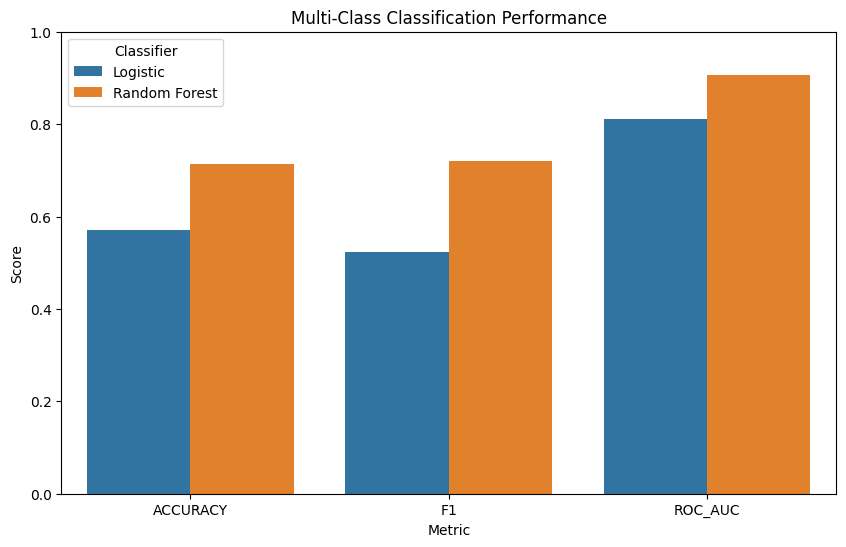

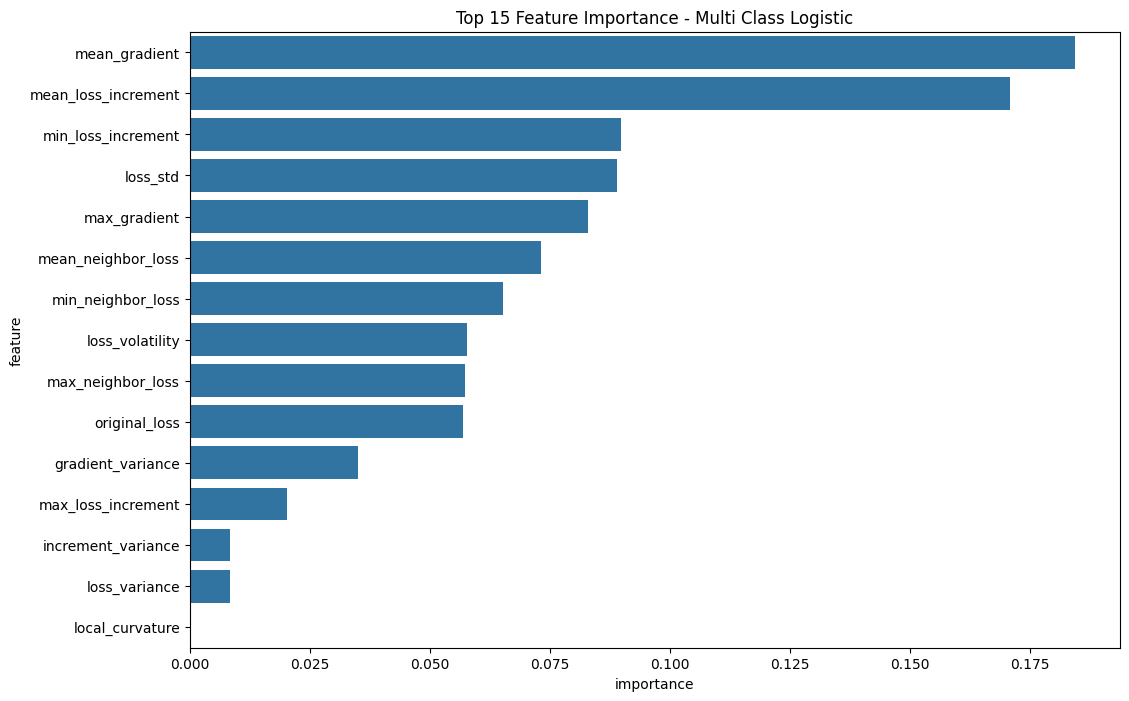

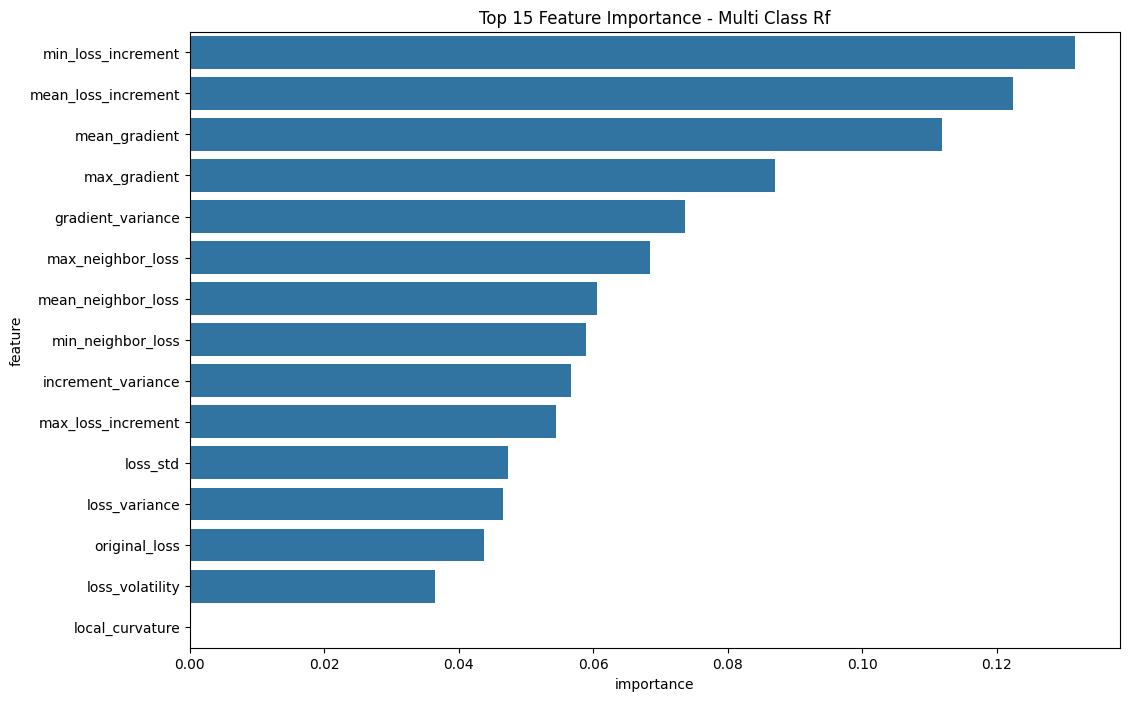

In [ ]:
# Train predictors to distinguish between TOFU datasets
# from sklearn.linear_model import LogisticRegression
# from sklearn.ensemble import RandomForestClassifier
# from sklearn.model_selection import train_test_split
# from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
# import pandas as pd

# Get feature labels from the features dictionary
features_labels = features_dict['forget']['features_names']

print("Training predictors for TOFU dataset classification...")
# Train predictors using normalized tensors
results, feature_importance_results = eval_with_ILL.train_predictors(
    retain_t=norm_retain_tensor,
    holdout_t=norm_holdout_tensor,
    features_labels=features_labels,
    forget_t=norm_forget_tensor
)

print("\n=== TOFU Classification Results ===")
for metric in ['accuracy', 'f1', 'roc_auc']:
    print(f"Logistic Regression {metric.upper()}: {results['multi_class']['logistic'][metric]:.3f}")
    print(f"Random Forest {metric.upper()}: {results['multi_class']['random_forest'][metric]:.3f}")
    print()

# Create classification plots
print("Creating classification visualization plots...")
classification_plots = eval_with_ILL.plot_classification_results(results, feature_importance_results)

Creating confusion matrices...


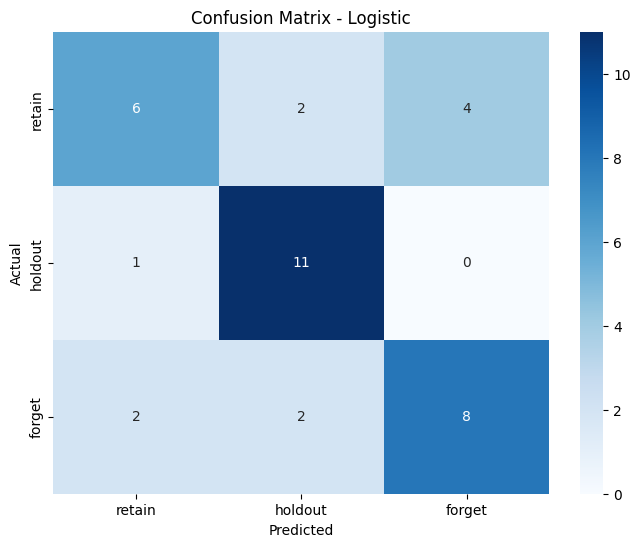

\n=== Classification Report - Logistic ===
              precision    recall  f1-score   support

      retain       0.67      0.50      0.57        12
     holdout       0.73      0.92      0.81        12
      forget       0.67      0.67      0.67        12

    accuracy                           0.69        36
   macro avg       0.69      0.69      0.68        36
weighted avg       0.69      0.69      0.68        36



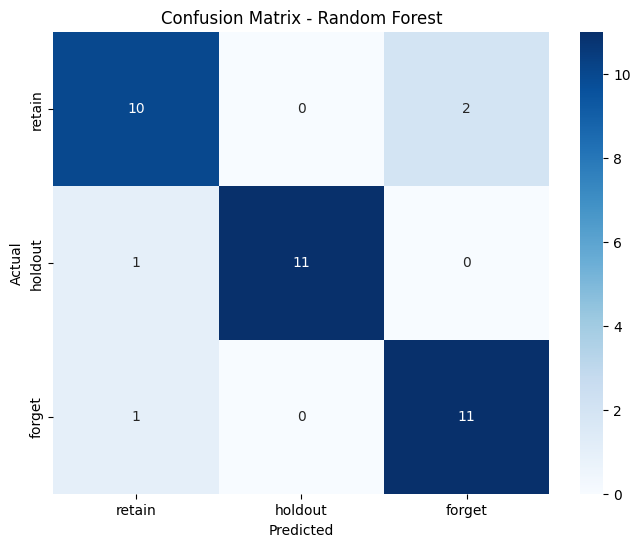

\n=== Classification Report - Random Forest ===
              precision    recall  f1-score   support

      retain       0.83      0.83      0.83        12
     holdout       1.00      0.92      0.96        12
      forget       0.85      0.92      0.88        12

    accuracy                           0.89        36
   macro avg       0.89      0.89      0.89        36
weighted avg       0.89      0.89      0.89        36

Analyzing prediction confidence...


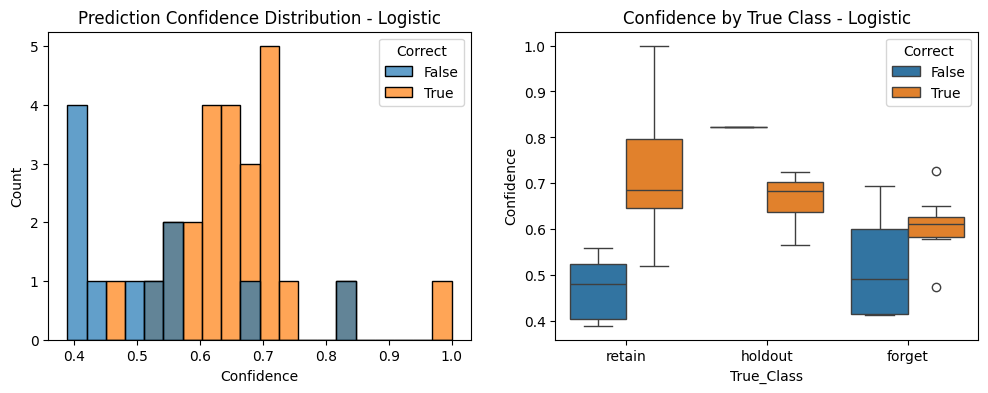

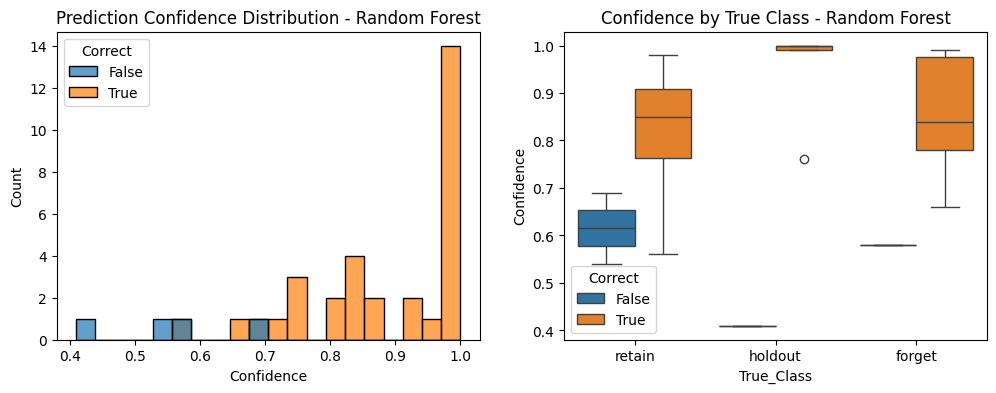

Generating ROC curves...


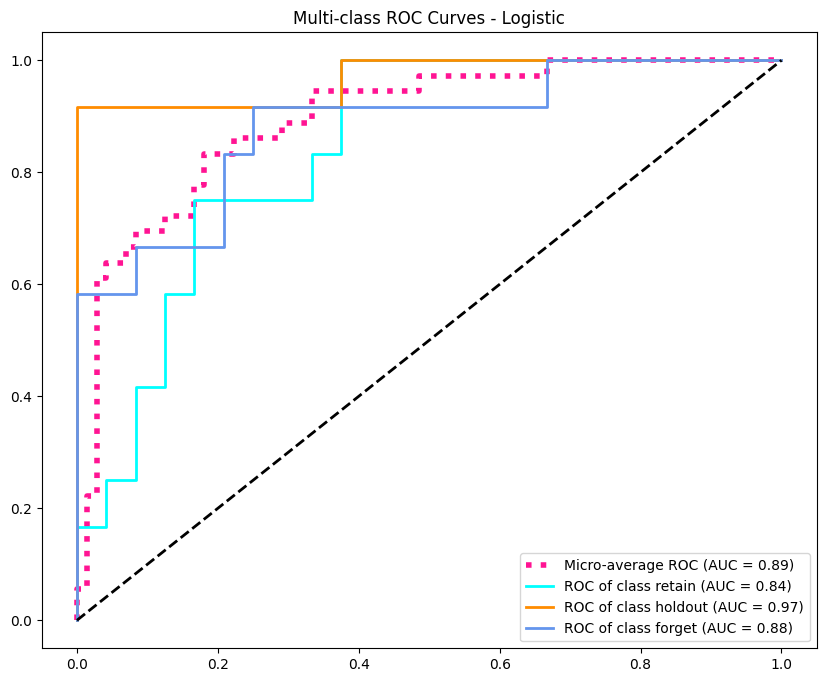

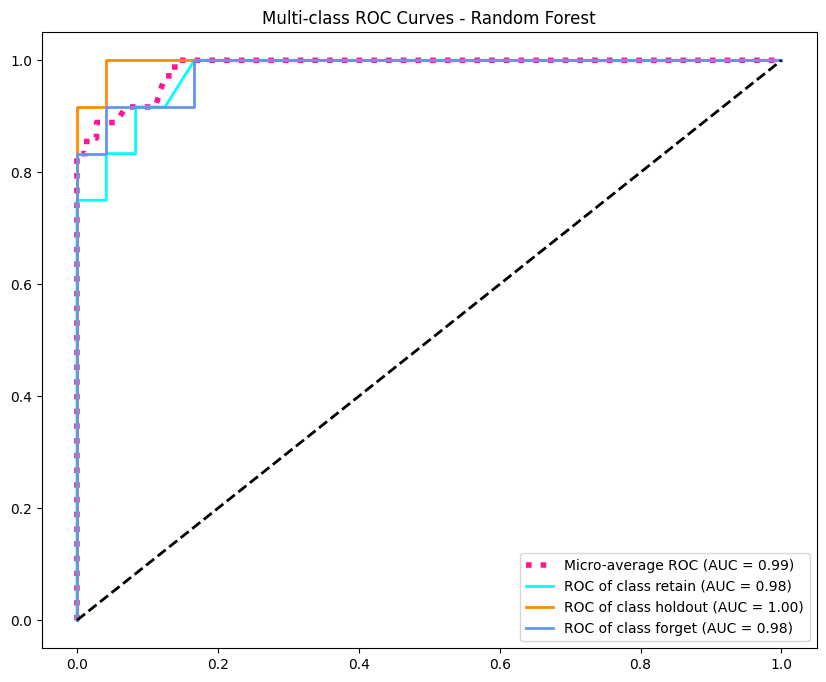


=== Summary ===
Classification analysis completed for TOFU datasets!
Generated plots show:
- Performance comparison between classifiers
- Feature importance for distinguishing forget/retain/holdout data
- Confusion matrices showing classification accuracy
- ROC curves for multi-class classification
- Prediction confidence analysis


In [ ]:
# Display confusion matrices and ROC curves
print("Creating confusion matrices...")
eval_with_ILL.plot_confusion_matrices(results, norm_retain_tensor, norm_holdout_tensor, norm_forget_tensor)

print("Analyzing prediction confidence...")
eval_with_ILL.analyze_prediction_confidence(results, norm_retain_tensor, norm_holdout_tensor, norm_forget_tensor)

print("Generating ROC curves...")
eval_with_ILL.plot_multiclass_roc_curves(results, norm_retain_tensor, norm_holdout_tensor, norm_forget_tensor)

print("\n=== Summary ===")
print("Classification analysis completed for TOFU datasets!")
print("Generated plots show:")
print("- Performance comparison between classifiers")
print("- Feature importance for distinguishing forget/retain/holdout data")
print("- Confusion matrices showing classification accuracy")
print("- ROC curves for multi-class classification")
print("- Prediction confidence analysis")

In [ ]:
# print(f"{comparison_results=}")

In [ ]:
# binary_results

Running binary comparisons between TOFU dataset pairs...


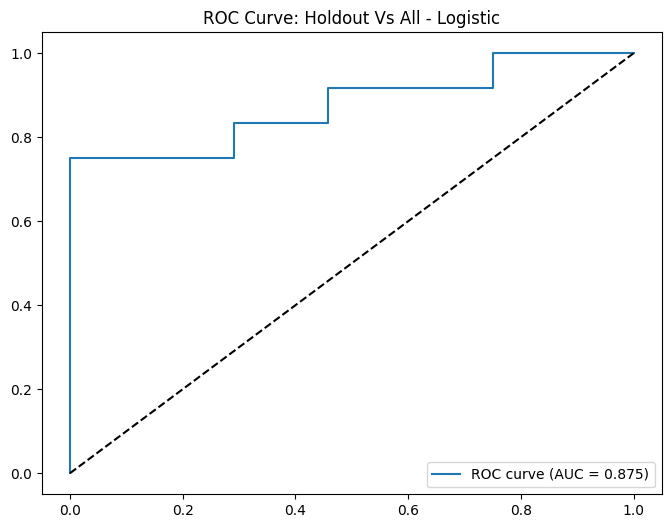

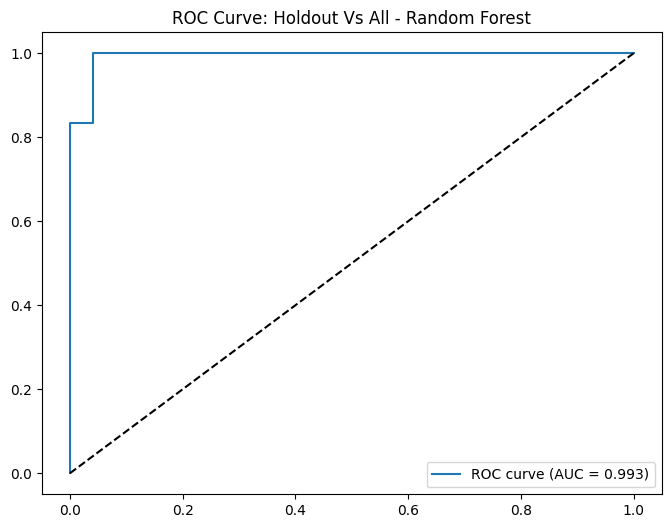

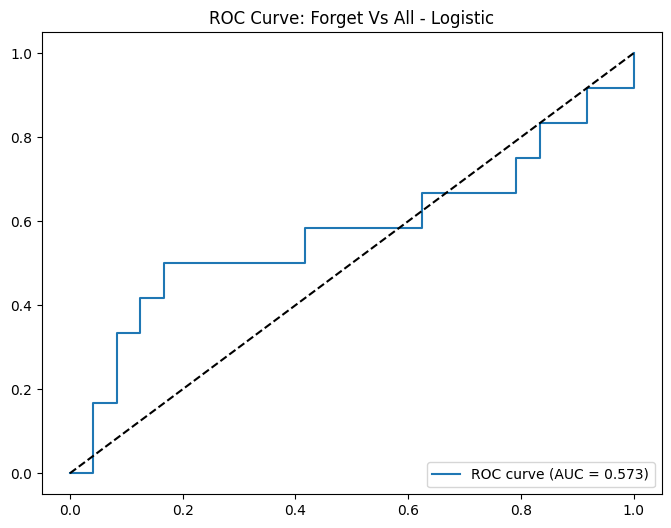

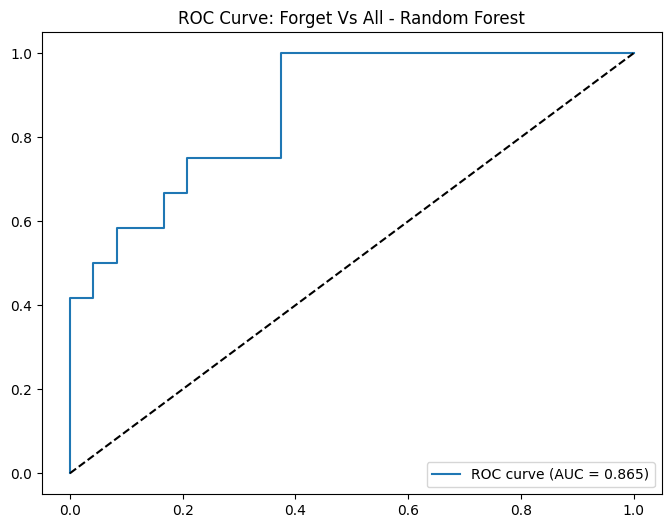

Creating comprehensive analysis summary...


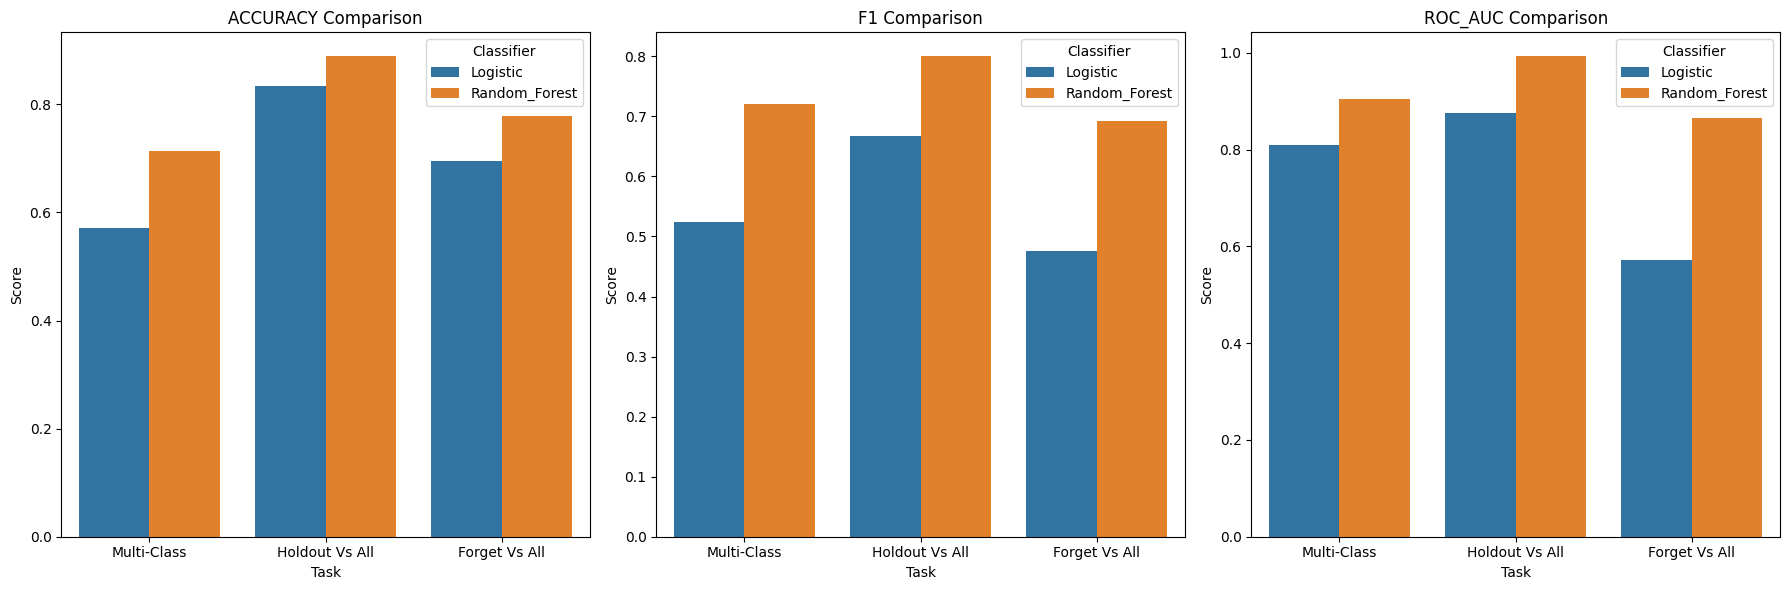


=== Binary Classification Results ===

Holdout Vs Vs Vs All:
  Accuracy: 0.833
  F1 Score: 0.667
  ROC AUC: 0.875

Holdout Vs Vs Vs All:
  Accuracy: 0.889
  F1 Score: 0.800
  ROC AUC: 0.993

Forget Vs Vs Vs All:
  Accuracy: 0.694
  F1 Score: 0.476
  ROC AUC: 0.573

Forget Vs Vs Vs All:
  Accuracy: 0.778
  F1 Score: 0.692
  ROC AUC: 0.865


In [ ]:
# Run binary comparisons between dataset pairs
print("Running binary comparisons between TOFU dataset pairs...")
binary_results, binary_feature_importance = eval_with_ILL.train_binary_comparisons(
    norm_retain_tensor, norm_holdout_tensor, norm_forget_tensor, features_labels
)

# Create comprehensive summary
print("Creating comprehensive analysis summary...")
comprehensive_plots = eval_with_ILL.create_comprehensive_summary(
    results, binary_results, feature_importance_results, binary_feature_importance
)

print("\n=== Binary Classification Results ===")
for comparison_name, comparison_results in binary_results.items():
    for classifier_type, c_comparison_results in comparison_results.items():
        print(f"\n{comparison_name.replace('_', ' vs ').title()}:")
        print(f"  Accuracy: {c_comparison_results['accuracy']:.3f}")
        print(f"  F1 Score: {c_comparison_results['f1']:.3f}")
        print(f"  ROC AUC: {c_comparison_results['roc_auc']:.3f}")

# Input Loss Landscape (ILL) Discriminative Analysis for TOFU Dataset

This section provides specialized methods to analyze and distinguish between **forget**, **retain**, and **holdout** datasets from the TOFU (Task of Fictitious Unlearning) benchmark using Input Loss Landscape features.

## TOFU Dataset Overview:
- **Forget**: Fictitious author information that should be "forgotten" (1% subset)
- **Retain**: Fictitious author information that should be retained (99% subset)  
- **Holdout**: Real author information for evaluation

## ILL Features Used:
- **Loss-based**: `original_loss`, `mean_neighbor_loss`, `max_neighbor_loss`, `min_neighbor_loss`
- **Variance-based**: `loss_variance`, `loss_std`, `increment_variance`
- **Gradient-based**: `mean_gradient`, `max_gradient`, `gradient_variance`
- **Landscape properties**: `loss_volatility`, `local_curvature`
- **Increment-based**: `mean_loss_increment`, `max_loss_increment`, `min_loss_increment`
- **Embeddings**: Sentence embeddings for semantic analysis

The goal is to identify which ILL features are most discriminative for distinguishing between the TOFU dataset types and understand the loss landscape characteristics of machine unlearning scenarios.

In [ ]:
# Advanced Statistical Analysis for TOFU ILL Features
# from scipy.stats import wasserstein_distance, ks_2samp, entropy, skew, kurtosis
# from scipy.spatial.distance import jensenshannon, pdist, squareform
# from sklearn.manifold import TSNE, Isomap
# from sklearn.decomposition import PCA
# from sklearn.cluster import KMeans, DBSCAN
# from sklearn.metrics import silhouette_score, adjusted_rand_score, accuracy_score, roc_auc_score
# from sklearn.linear_model import LogisticRegression
# import seaborn as sns
# import numpy as np
# import matplotlib.pyplot as plt

# Try to import UMAP, install if not available
try:
    import umap
    UMAP_AVAILABLE = True
    print("UMAP available for manifold analysis")
except ImportError:
    print("UMAP not available. Install with: pip install umap-learn")
    UMAP_AVAILABLE = False

# Compute statistical distances between TOFU datasets
print("Computing statistical distances between TOFU datasets...")
stat_distances = eval_with_ILL.compute_statistical_distances(
    norm_retain_tensor, norm_holdout_tensor, norm_forget_tensor, features_labels
)

print("Statistical distance computation completed!")

UMAP available for manifold analysis
Computing statistical distances between TOFU datasets...
Statistical distance computation completed!


Plotting statistical distances heatmap...


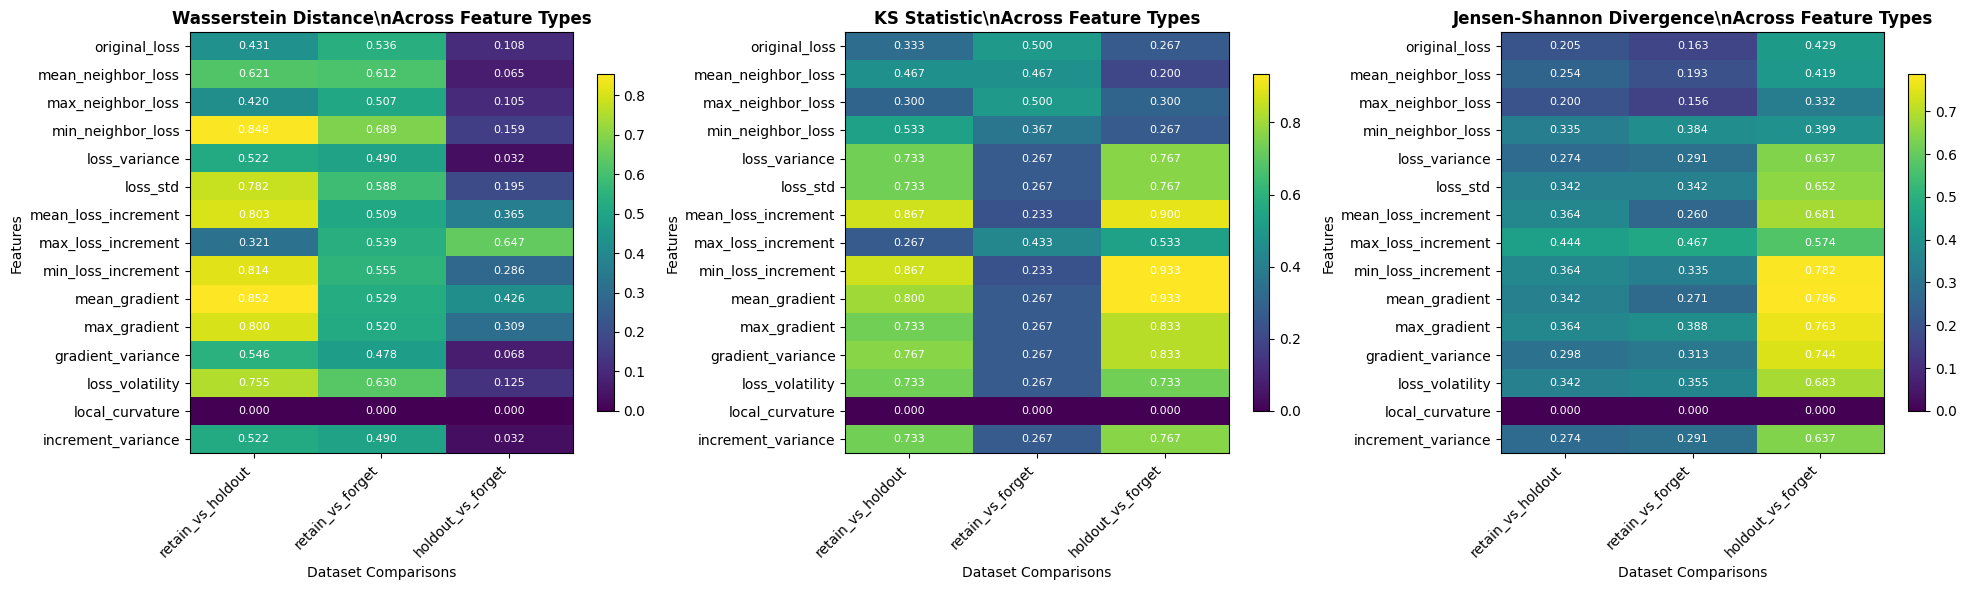

Analyzing manifold structures for TOFU datasets...
Computing PCA embedding...
Computing TSNE embedding...
Computing Isomap embedding...
Computing UMAP embedding...


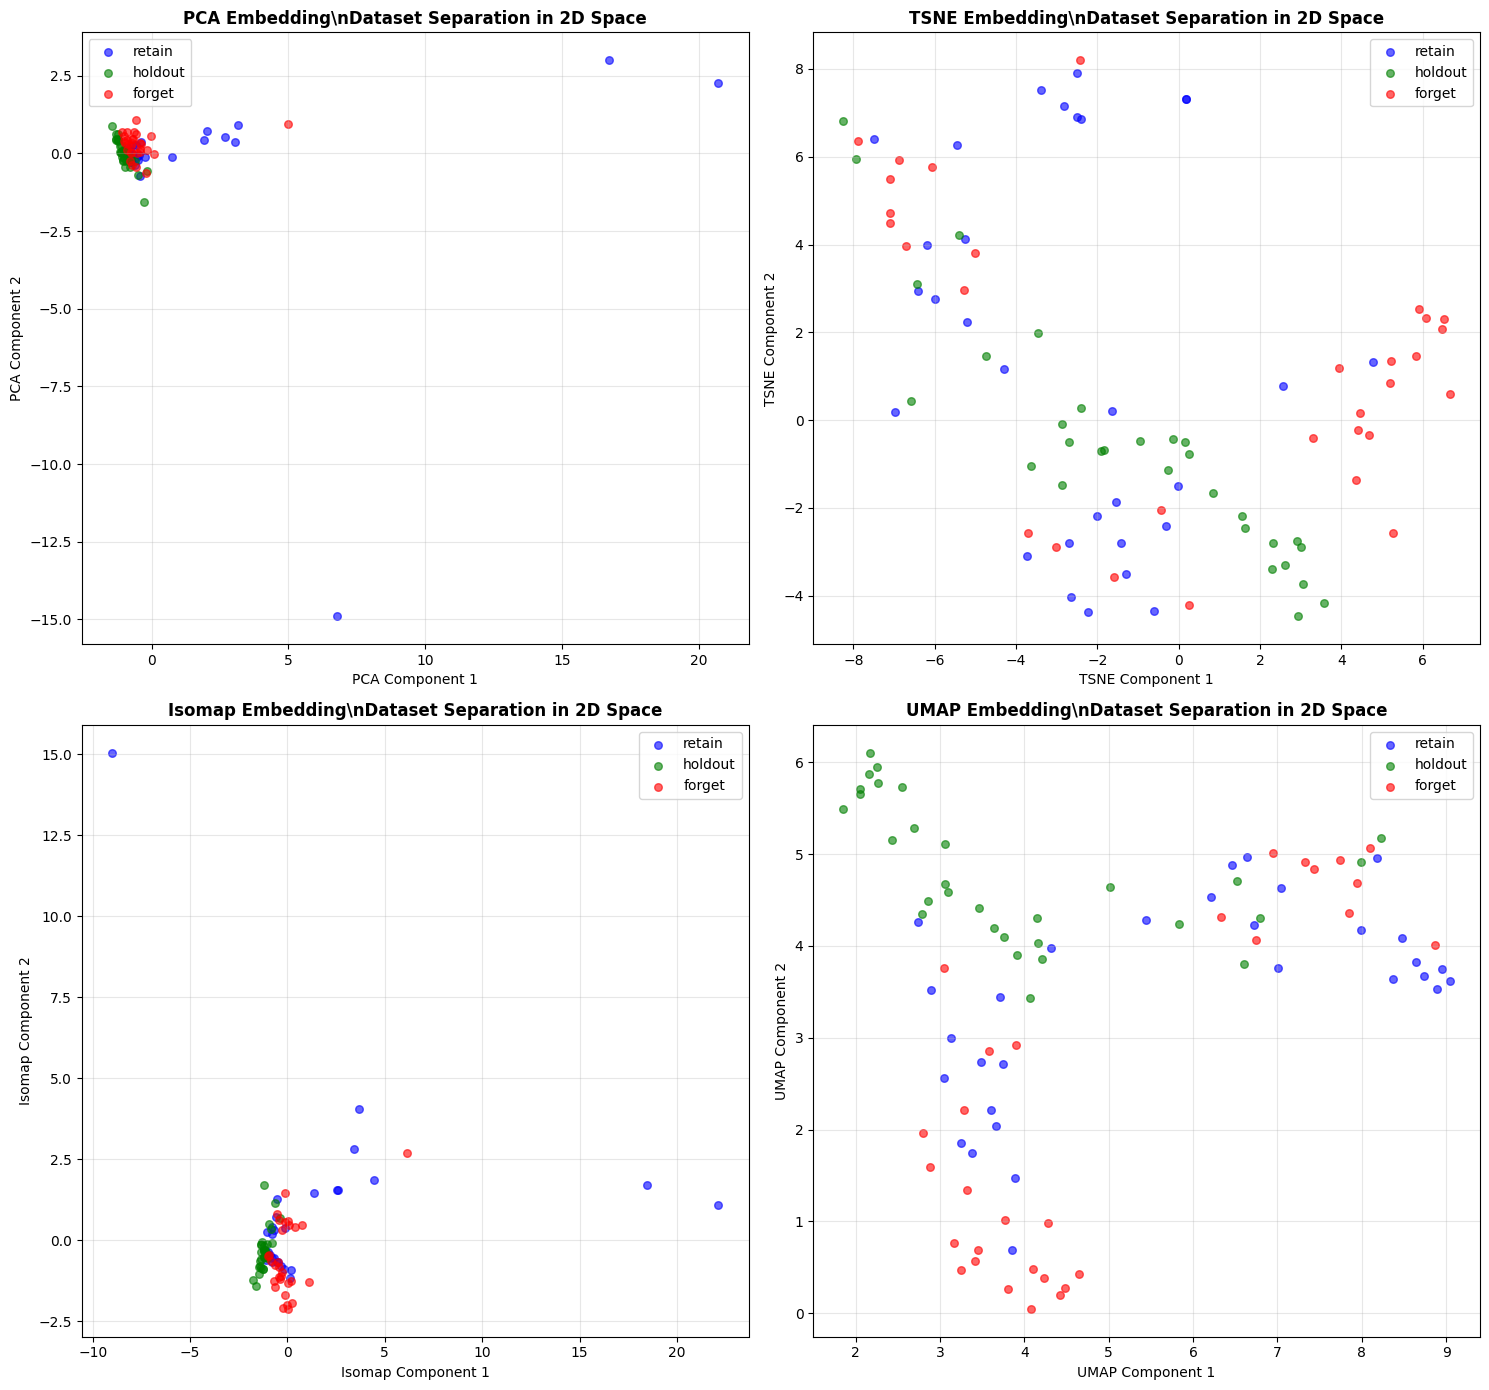

Manifold analysis shows how well TOFU datasets can be separated in reduced dimensions
Look for distinct clusters in the plots - well-separated clusters indicate
that the datasets have different loss landscape characteristics


In [ ]:
# Visualize statistical distances between TOFU datasets
print("Plotting statistical distances heatmap...")
eval_with_ILL.plot_statistical_distances(stat_distances, features_labels)

# Perform manifold analysis to visualize dataset separability
print("Analyzing manifold structures for TOFU datasets...")
manifold_results = eval_with_ILL.compare_manifold_structures(
    norm_retain_tensor, norm_holdout_tensor, norm_forget_tensor
)

print("Manifold analysis shows how well TOFU datasets can be separated in reduced dimensions")
print("Look for distinct clusters in the plots - well-separated clusters indicate")
print("that the datasets have different loss landscape characteristics")

In [ ]:
# Run transfer analysis
print("Analyzing prediction transfer...")
transfer_results = eval_with_ILL.analyze_prediction_transfer(norm_retain_tensor, norm_holdout_tensor, norm_forget_tensor)

Analyzing prediction transfer...


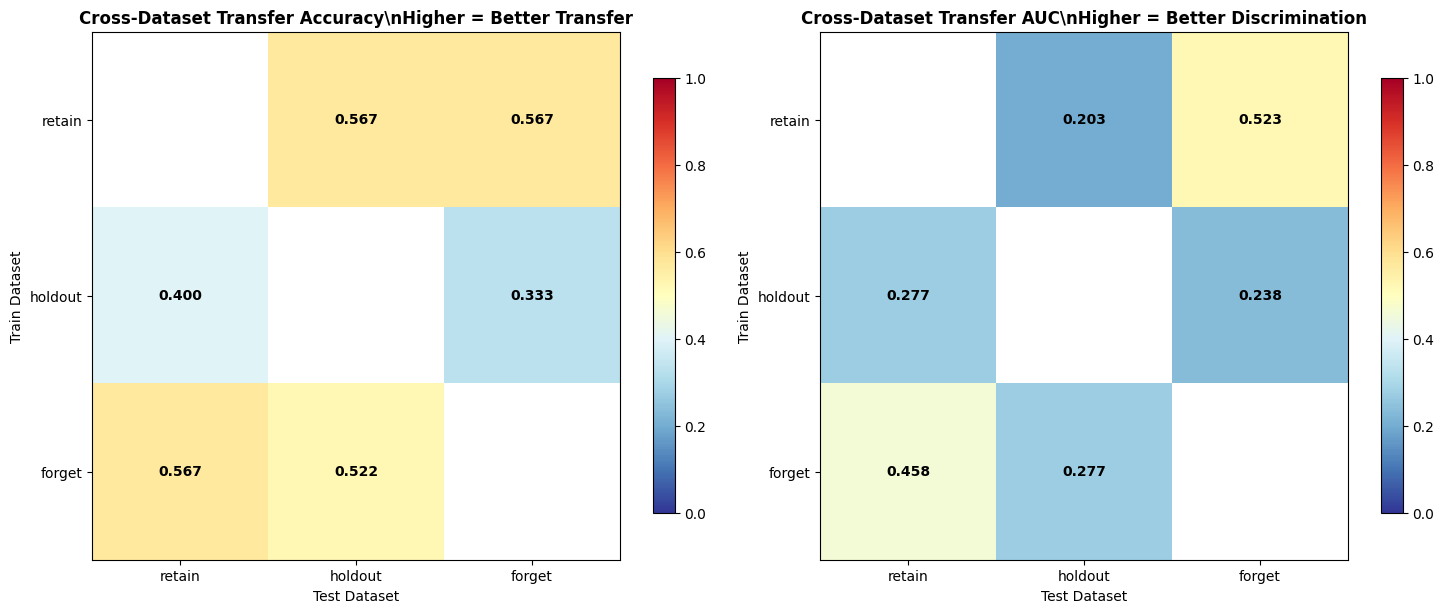

In [ ]:
# Plot transfer results
eval_with_ILL.plot_transfer_results(transfer_results)

Analyzing ILL feature discrimination for TOFU unlearning scenarios...
ILL FEATURE DISCRIMINATION ANALYSIS
Cross-validation accuracy: 0.700 (+/- 0.229)
Overall classification accuracy: 1.000

Top 5 Most Discriminative ILL Features:
1. mean_loss_increment: 0.1313
2. min_loss_increment: 0.1294
3. mean_gradient: 0.1123
4. gradient_variance: 0.0860
5. max_neighbor_loss: 0.0683
Creating ILL discrimination visualization...


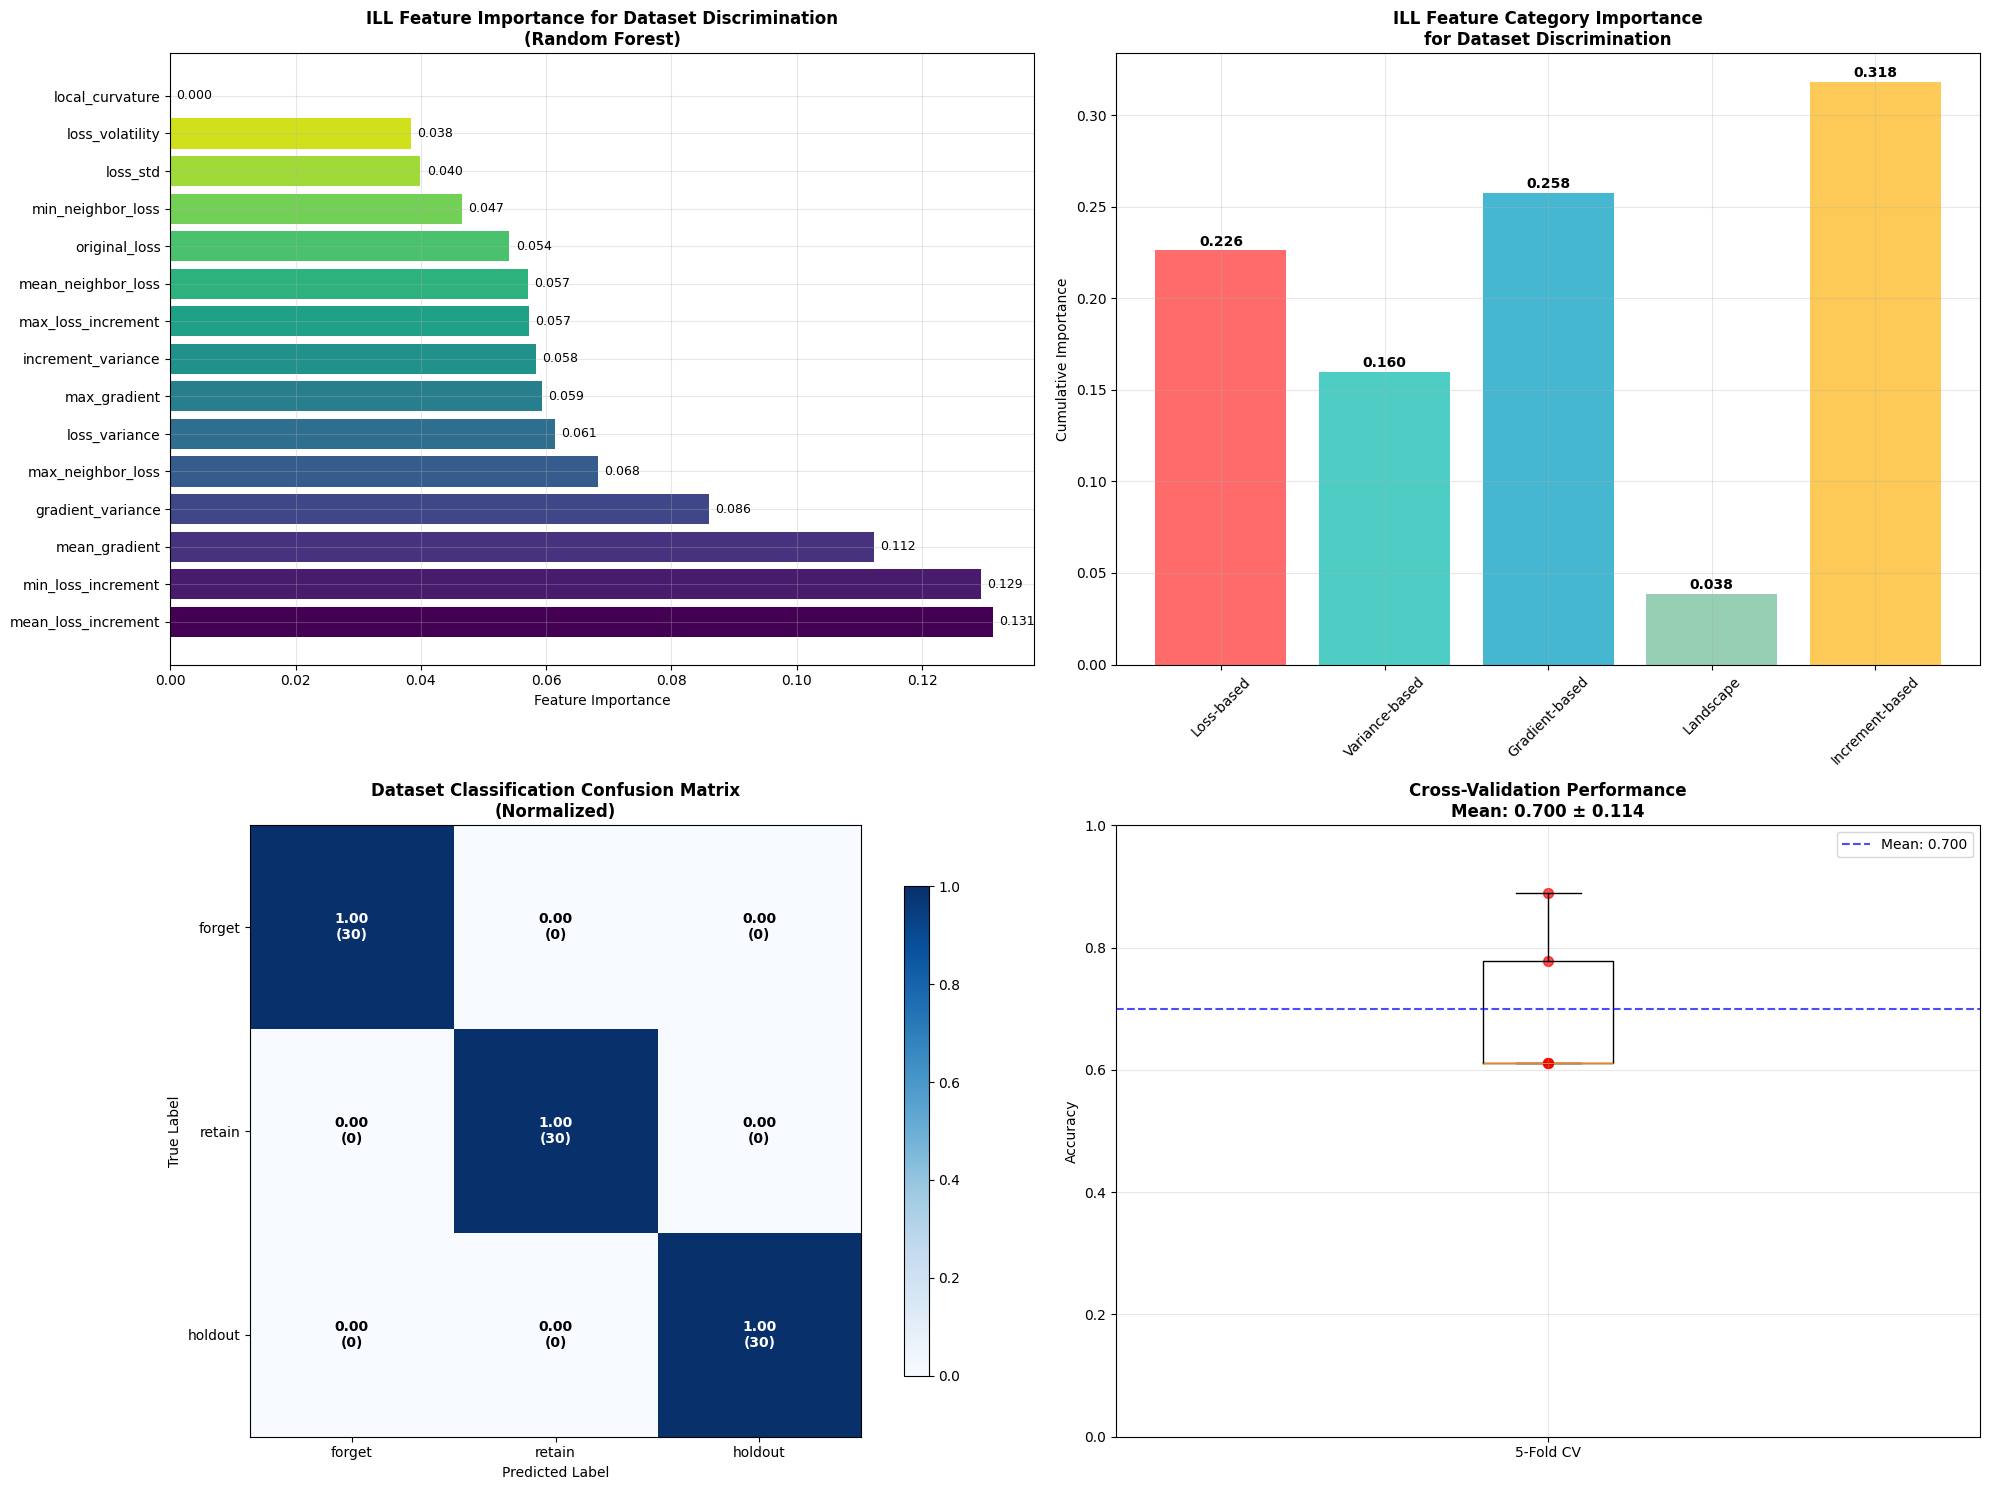

Analyzing loss landscape topology for TOFU machine unlearning...
LOSS LANDSCAPE TOPOLOGY DISCRIMINATION ANALYSIS

LOSS FEATURES:
------------------------------
  forget vs retain:
    Average effect size: 0.510
    Max effect size: 0.613
  forget vs holdout:
    Average effect size: 0.313
    Max effect size: 0.463
  retain vs holdout:
    Average effect size: 0.510
    Max effect size: 0.781

VARIANCE FEATURES:
------------------------------
  forget vs retain:
    Average effect size: 0.447
    Max effect size: 0.511
  forget vs holdout:
    Average effect size: 0.455
    Max effect size: 0.723
  retain vs holdout:
    Average effect size: 0.529
    Max effect size: 0.700

GRADIENT FEATURES:
------------------------------
  forget vs retain:
    Average effect size: 0.402
    Max effect size: 0.428
  forget vs holdout:
    Average effect size: 1.001
    Max effect size: 2.063
  retain vs holdout:
    Average effect size: 0.665
    Max effect size: 0.765

LANDSCAPE FEATURES:
---------

In [ ]:
# Specialized ILL Discrimination Analysis for TOFU Unlearning
print("Analyzing ILL feature discrimination for TOFU unlearning scenarios...")

# Run ILL-specific discrimination analysis
ill_discrimination = eval_with_ILL.analyze_ill_feature_discrimination(
    norm_retain_tensor, norm_holdout_tensor, norm_forget_tensor, features_labels
)

# Plot discrimination analysis results
print("Creating ILL discrimination visualization...")
eval_with_ILL.plot_ill_discrimination_analysis(ill_discrimination, features_labels)

# Analyze loss landscape topology for machine unlearning
print("Analyzing loss landscape topology for TOFU machine unlearning...")
topology_discrimination = eval_with_ILL.analyze_loss_landscape_topology_discrimination(
    norm_retain_tensor, norm_holdout_tensor, norm_forget_tensor, features_labels
)

# Analyze decision boundaries in the loss landscape
print("Analyzing loss landscape boundaries for TOFU datasets...")
boundary_results = eval_with_ILL.analyze_loss_landscape_boundaries(
    norm_retain_tensor, norm_holdout_tensor, norm_forget_tensor, features_labels
)

Analyzing pairwise discrimination between TOFU dataset combinations...
PAIRWISE DISCRIMINATION ANALYSIS

FORGET vs RETAIN:
-------------------------
Binary classification accuracy: 0.650 ± 0.143
Significant features: 3/15
Top 3 discriminative features:
  min_neighbor_loss: Cohen's d = 0.613, p = 0.0231
  loss_volatility: Cohen's d = -0.548, p = 0.0413
  mean_neighbor_loss: Cohen's d = 0.532, p = 0.0472

FORGET vs HOLDOUT:
-------------------------
Binary classification accuracy: 0.933 ± 0.062
Significant features: 6/15
Top 3 discriminative features:
  mean_loss_increment: Cohen's d = -2.181, p = 0.0000
  mean_gradient: Cohen's d = 2.063, p = 0.0000
  min_loss_increment: Cohen's d = -0.746, p = 0.0062

RETAIN vs HOLDOUT:
-------------------------
Binary classification accuracy: 0.883 ± 0.085
Significant features: 8/15
Top 3 discriminative features:
  min_neighbor_loss: Cohen's d = -0.781, p = 0.0043
  max_gradient: Cohen's d = 0.765, p = 0.0051
  mean_gradient: Cohen's d = 0.759, p = 0.

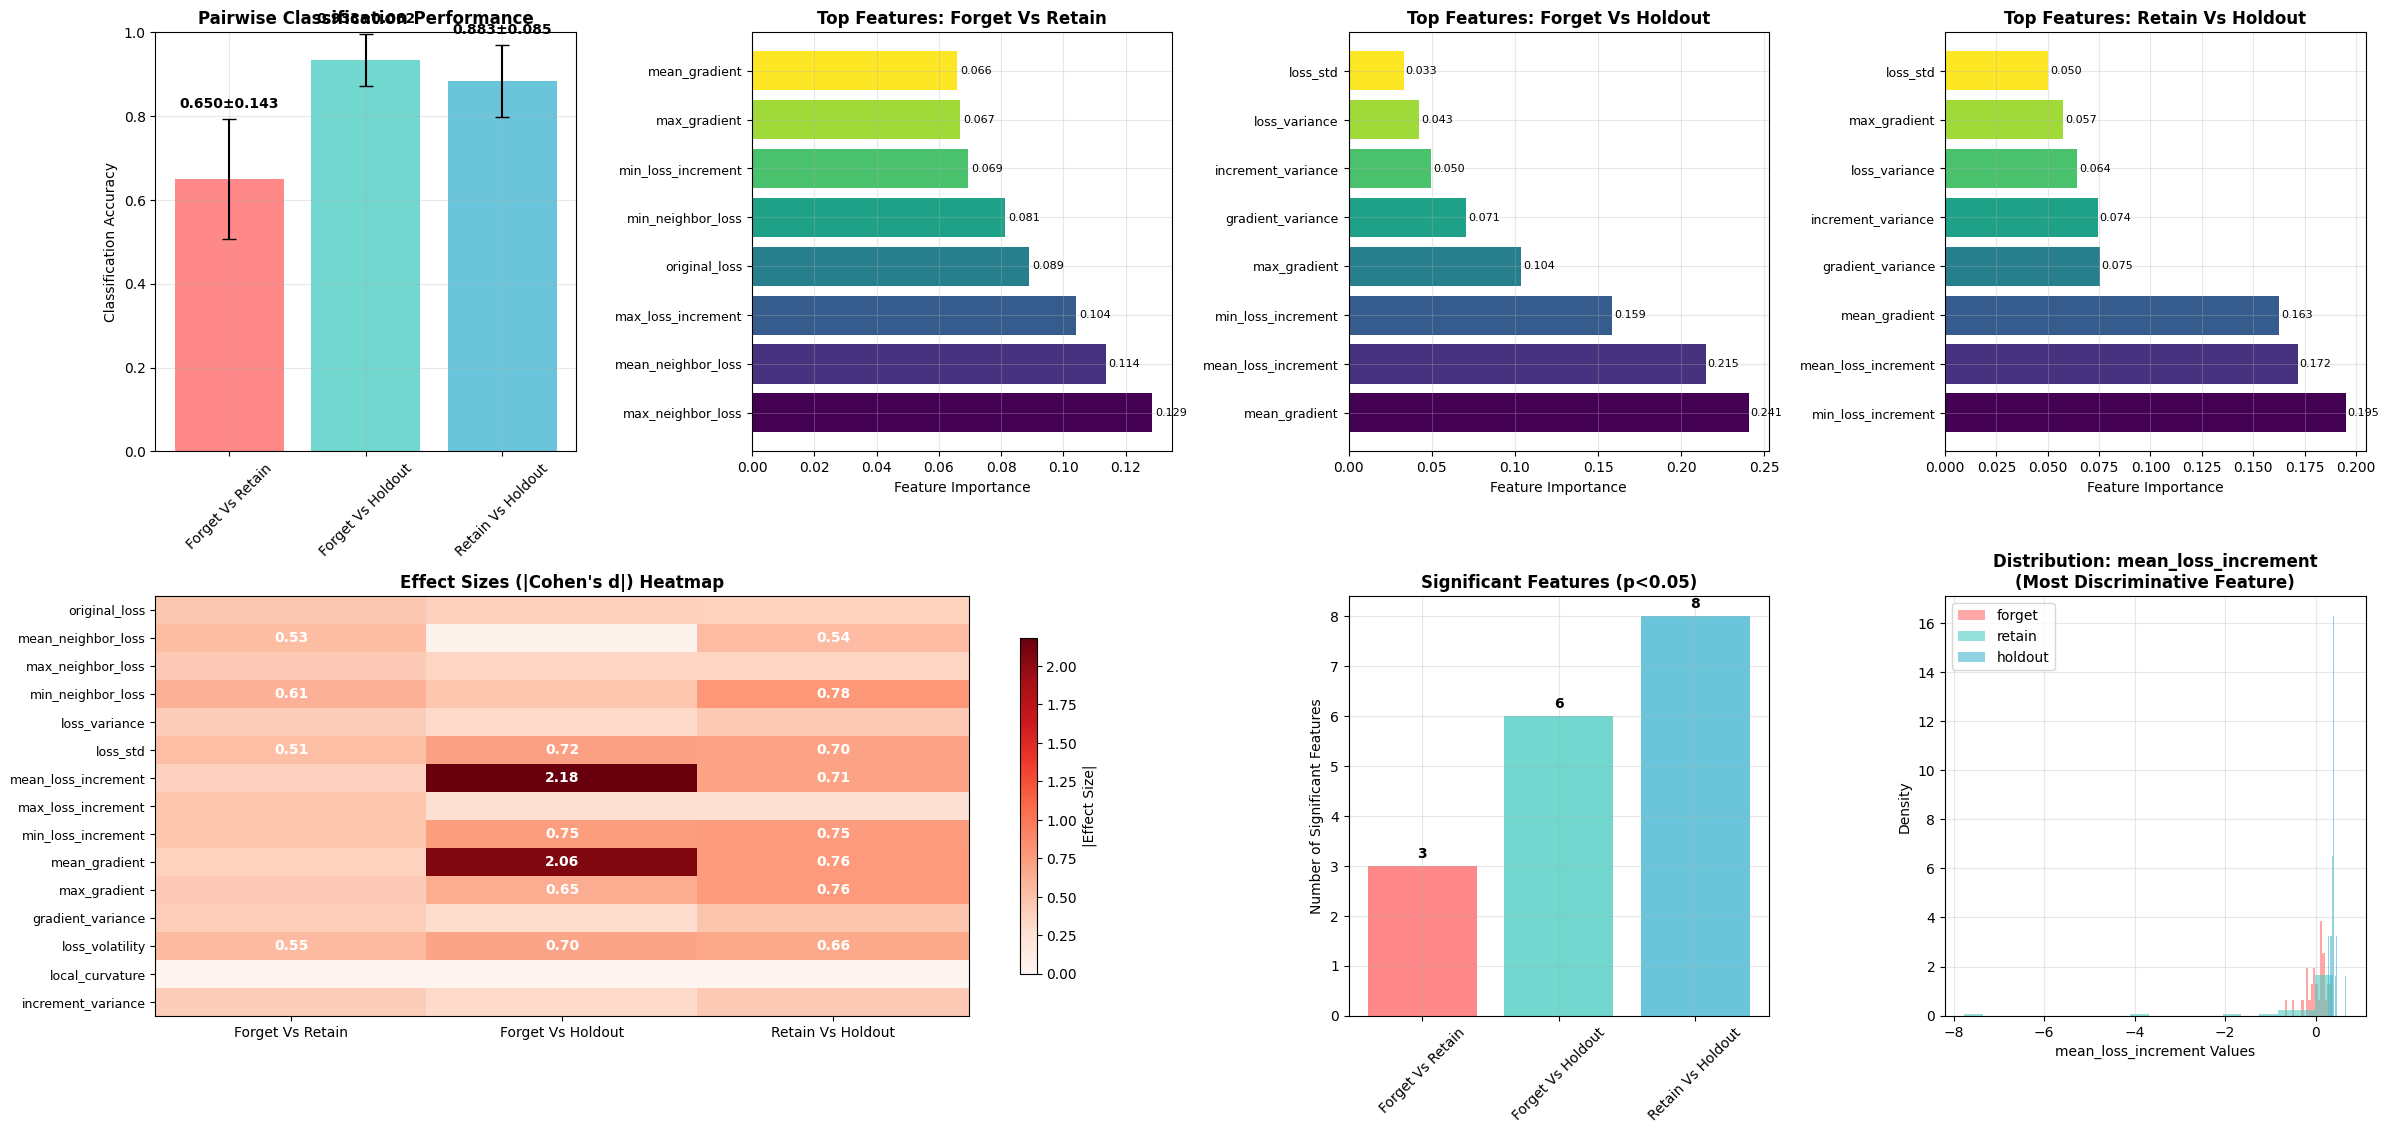


🎯 MOST DISCRIMINATIVE FEATURE FOR TOFU UNLEARNING: mean_loss_increment
   Average effect size across all dataset pairs: 1.089


In [ ]:
# Pairwise Discrimination Analysis for TOFU Dataset Pairs
print("Analyzing pairwise discrimination between TOFU dataset combinations...")
pairwise_results = eval_with_ILL.analyze_pairwise_discrimination(
    norm_retain_tensor, norm_holdout_tensor, norm_forget_tensor, features_labels
)

# Generate comprehensive pairwise discrimination plots and identify best features
print("Creating comprehensive pairwise discrimination results...")
best_discriminative_feature, feature_discrimination_scores = eval_with_ILL.plot_pairwise_discrimination_results(
    pairwise_results, features_labels, norm_retain_tensor, norm_holdout_tensor, norm_forget_tensor
)

print(f"\n🎯 MOST DISCRIMINATIVE FEATURE FOR TOFU UNLEARNING: {best_discriminative_feature}")
print(f"   Average effect size across all dataset pairs: {feature_discrimination_scores[best_discriminative_feature]:.3f}")

# This feature is most useful for distinguishing between forget/retain/holdout data in unlearning scenarios!

In [ ]:
# Specialized Input Loss Landscape (ILL) Analysis Functions

def analyze_loss_landscape_categories(norm_retain_tensor, norm_holdout_tensor, norm_forget_tensor, features_labels):
    """
    Analyze loss landscape features by semantic categories relevant to ILL.
    """
    # Define feature categories for ILL analysis
    feature_categories = {
        'Base Loss': ['original_loss', 'mean_neighbor_loss', 'max_neighbor_loss', 'min_neighbor_loss'],
        'Variability': ['loss_variance', 'loss_std', 'increment_variance'],
        'Gradient': ['mean_gradient', 'max_gradient', 'gradient_variance'],
        'Landscape': ['loss_volatility', 'local_curvature'],
        'Increment': ['mean_loss_increment', 'max_loss_increment', 'min_loss_increment']
    }
    
    datasets = {
        'retain': norm_retain_tensor,
        'holdout': norm_holdout_tensor,
        'forget': norm_forget_tensor
    }
    
    category_analysis = {}
    
    # Analyze each category
    for category, features in feature_categories.items():
        category_data = {}
        
        for dataset_name, tensor in datasets.items():
            category_features = []
            for feature in features:
                if feature in features_labels:
                    feat_idx = features_labels.index(feature)
                    category_features.append(tensor[:, feat_idx].numpy())
            
            if category_features:
                category_tensor = np.column_stack(category_features)
                
                # Compute category-level statistics
                category_data[dataset_name] = {
                    'mean_values': np.mean(category_tensor, axis=0),
                    'std_values': np.std(category_tensor, axis=0),
                    'category_mean': np.mean(category_tensor),
                    'category_std': np.std(category_tensor),
                    'feature_correlations': np.corrcoef(category_tensor.T),
                    'feature_names': [f for f in features if f in features_labels]
                }
        
        category_analysis[category] = category_data
    
    return category_analysis

# Run category analysis
print("Analyzing ILL features by semantic categories...")
category_analysis = analyze_loss_landscape_categories(norm_retain_tensor, norm_holdout_tensor, norm_forget_tensor, features_labels)

Analyzing ILL features by semantic categories...


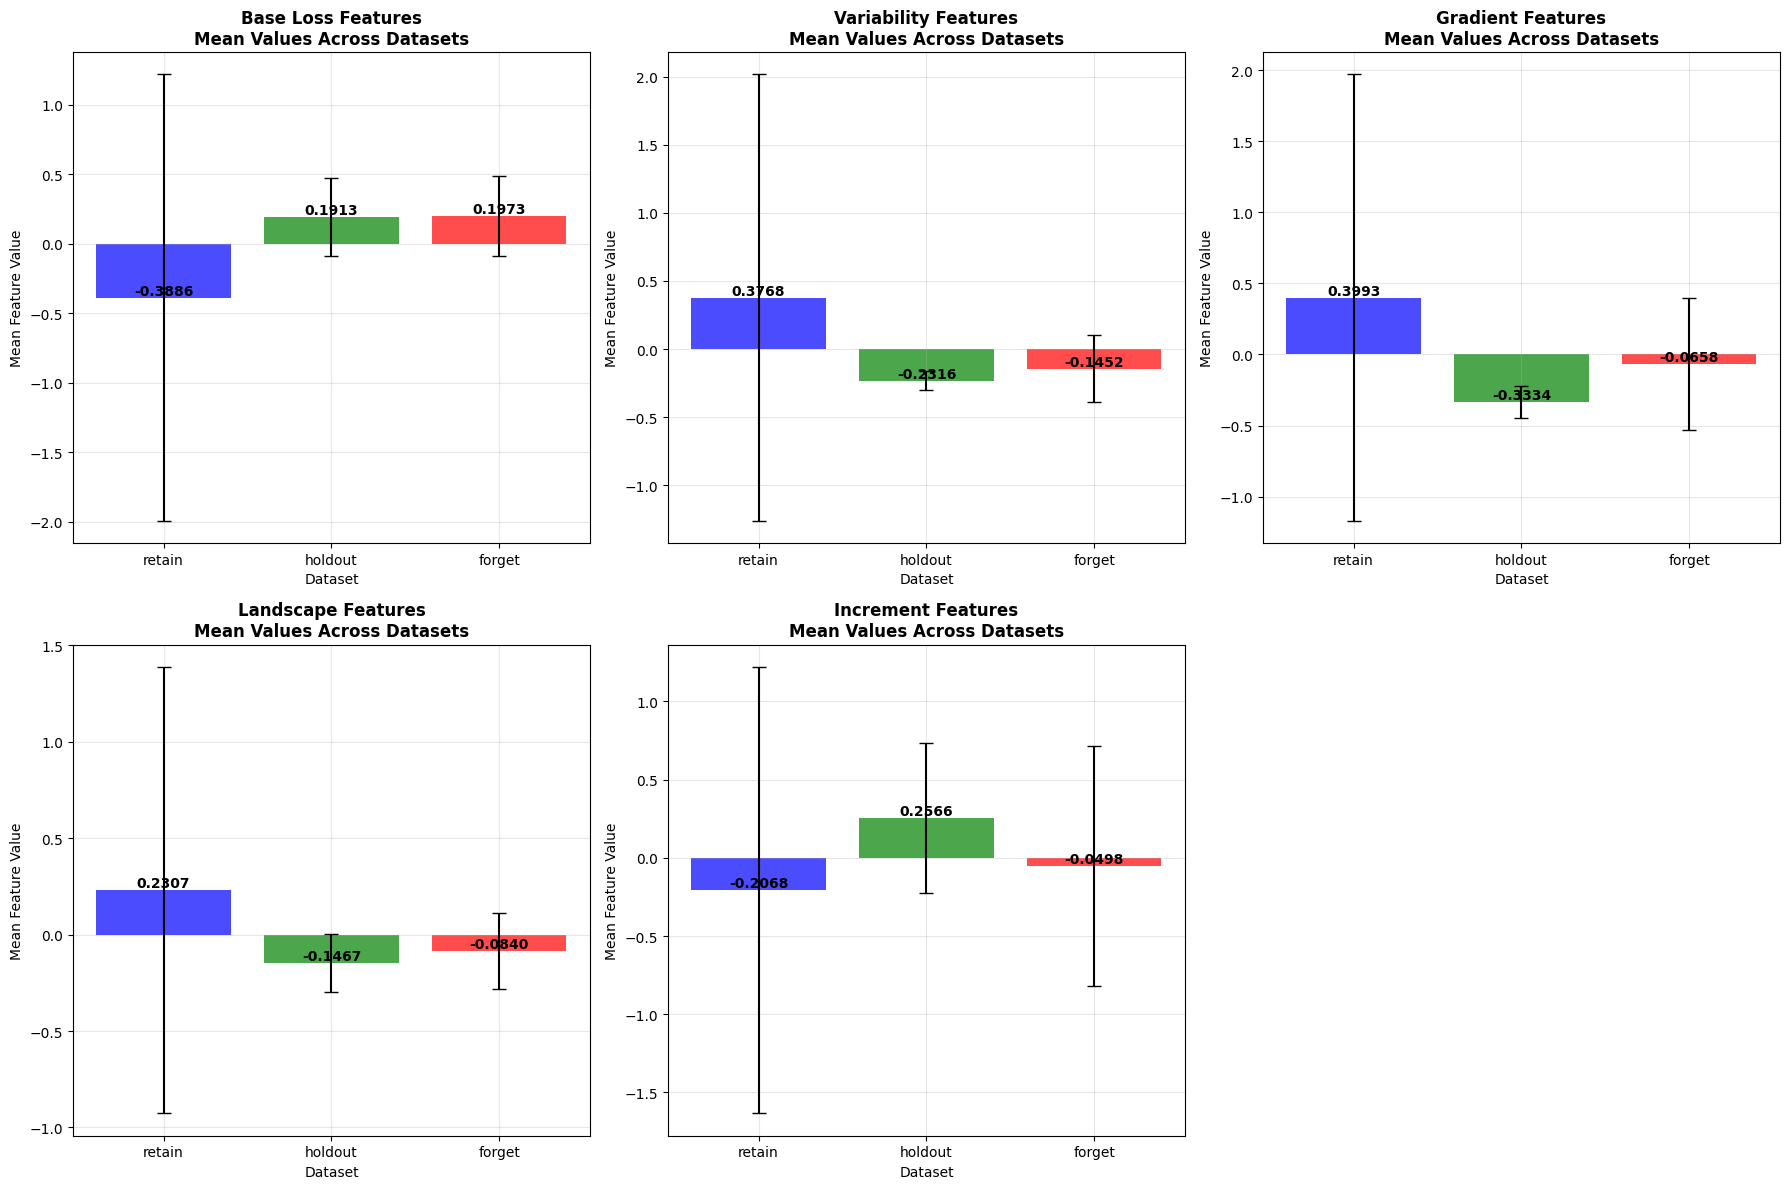

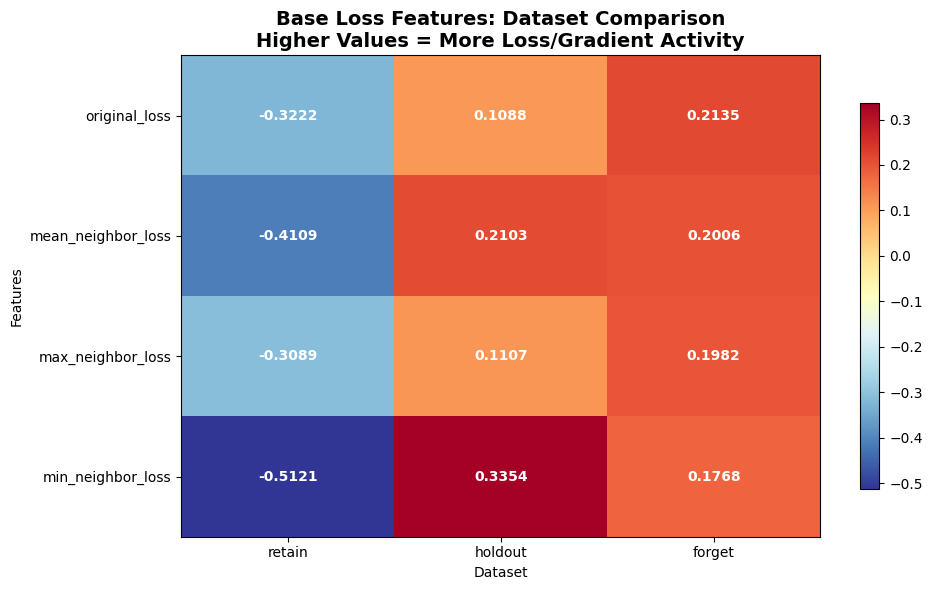

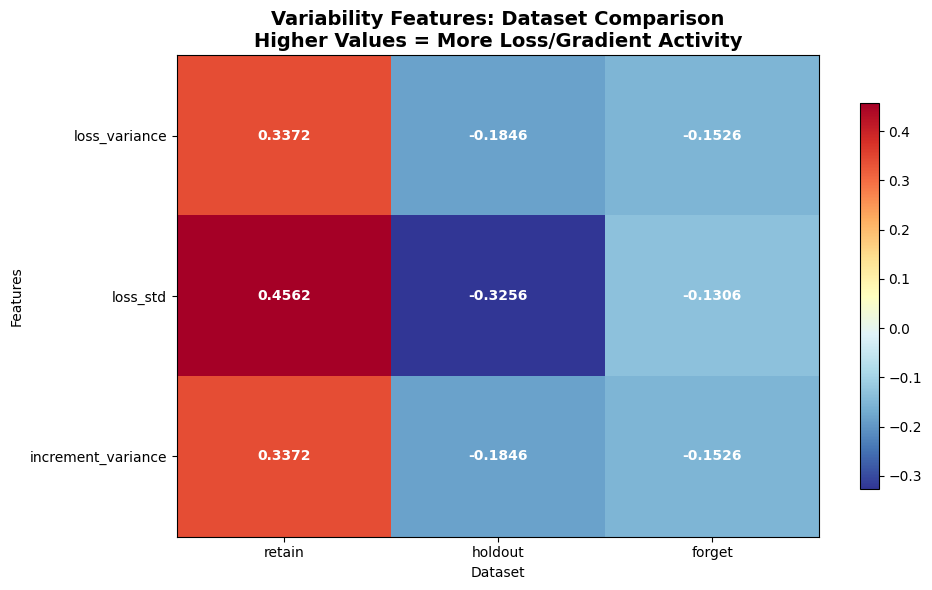

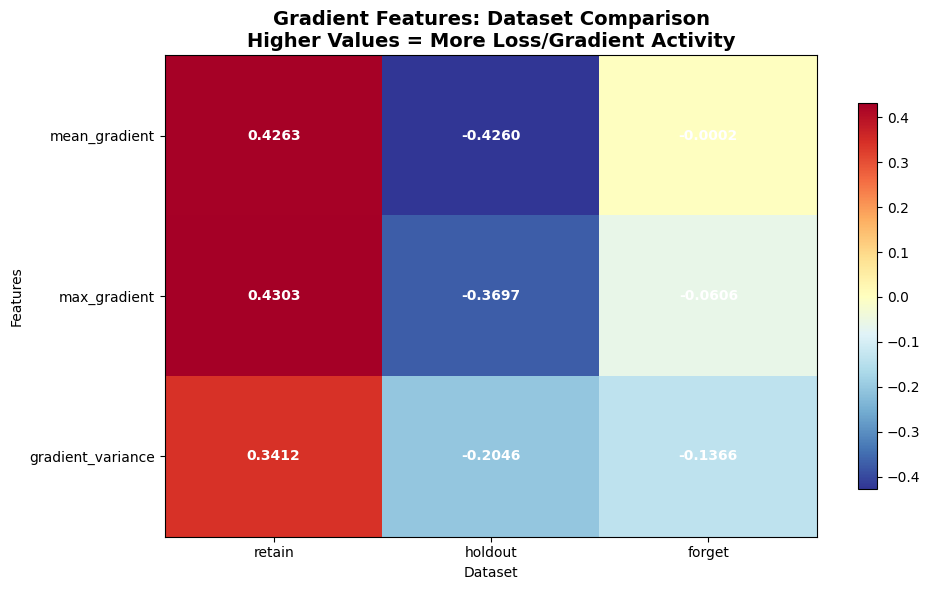

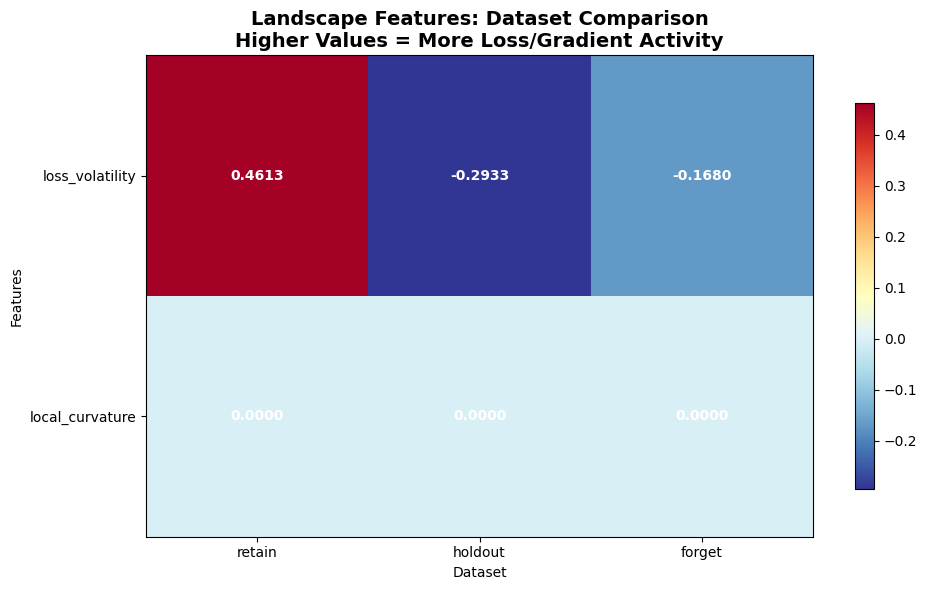

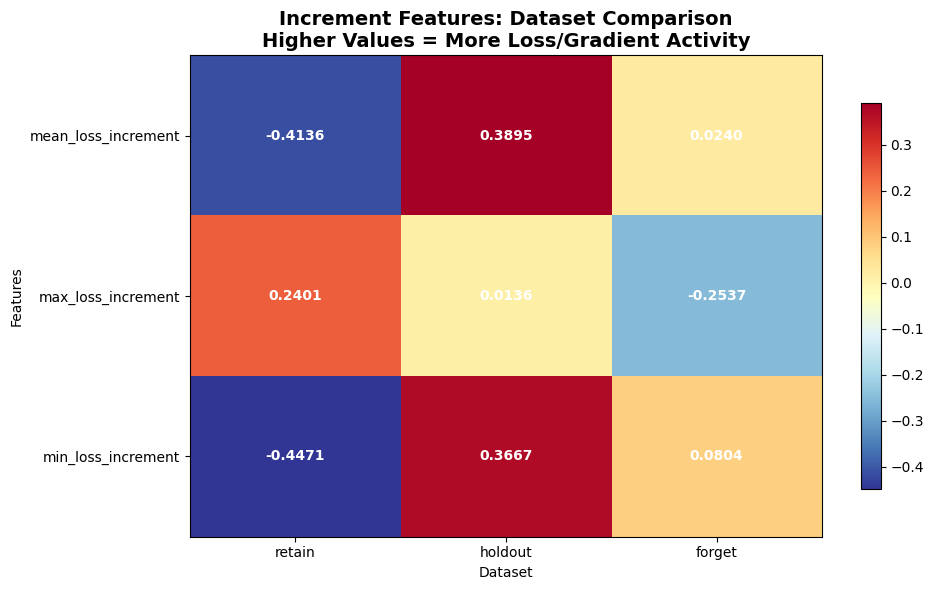

In [ ]:
# Visualize ILL Category Analysis
def plot_ill_category_analysis(category_analysis):
    """
    Create comprehensive visualizations for ILL category analysis.
    """
    categories = list(category_analysis.keys())
    datasets = ['retain', 'holdout', 'forget']
    colors = {'retain': 'blue', 'holdout': 'green', 'forget': 'red'}
    
    # 1. Category-level means comparison
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    axes = axes.flatten()
    
    for idx, category in enumerate(categories):
        ax = axes[idx]
        
        category_means = []
        category_stds = []
        
        for dataset in datasets:
            if dataset in category_analysis[category]:
                category_means.append(category_analysis[category][dataset]['category_mean'])
                category_stds.append(category_analysis[category][dataset]['category_std'])
            else:
                category_means.append(0)
                category_stds.append(0)
        
        x_pos = np.arange(len(datasets))
        bars = ax.bar(x_pos, category_means, yerr=category_stds, 
                     color=[colors[d] for d in datasets], alpha=0.7, capsize=5)
        
        ax.set_title(f'{category} Features\nMean Values Across Datasets', fontweight='bold')
        ax.set_xlabel('Dataset')
        ax.set_ylabel('Mean Feature Value')
        ax.set_xticks(x_pos)
        ax.set_xticklabels(datasets)
        ax.grid(True, alpha=0.3)
        
        # Add value labels on bars
        for bar, mean_val in zip(bars, category_means):
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                   f'{mean_val:.4f}', ha='center', va='bottom', fontweight='bold')
    
    # Hide unused subplot
    if len(categories) < len(axes):
        axes[-1].set_visible(False)
    
    plt.tight_layout()
    plt.savefig(f'{plots_base_dir}/ill_category_means.png', bbox_inches='tight', dpi=150)
    plt.show()
    
    # 2. Feature-level heatmap for each category
    for category in categories:
        if category not in category_analysis:
            continue
            
        # Get feature names for this category
        feature_names = None
        for dataset in datasets:
            if dataset in category_analysis[category]:
                feature_names = category_analysis[category][dataset]['feature_names']
                break
        
        if not feature_names:
            continue
            
        # Create data matrix
        data_matrix = []
        for feature_idx in range(len(feature_names)):
            row = []
            for dataset in datasets:
                if dataset in category_analysis[category]:
                    row.append(category_analysis[category][dataset]['mean_values'][feature_idx])
                else:
                    row.append(0)
            data_matrix.append(row)
        
        data_matrix = np.array(data_matrix)
        
        # Plot heatmap
        fig, ax = plt.subplots(figsize=(10, max(6, len(feature_names)*0.8)))
        im = ax.imshow(data_matrix, cmap='RdYlBu_r', aspect='auto')
        
        ax.set_title(f'{category} Features: Dataset Comparison\nHigher Values = More Loss/Gradient Activity', 
                    fontweight='bold', fontsize=14)
        ax.set_xlabel('Dataset')
        ax.set_ylabel('Features')
        ax.set_xticks(range(len(datasets)))
        ax.set_yticks(range(len(feature_names)))
        ax.set_xticklabels(datasets)
        ax.set_yticklabels(feature_names)
        
        # Add text annotations
        for i in range(len(feature_names)):
            for j in range(len(datasets)):
                text = ax.text(j, i, f'{data_matrix[i, j]:.4f}',
                              ha="center", va="center", color="white", fontweight='bold')
        
        plt.colorbar(im, ax=ax, shrink=0.8)
        plt.tight_layout()
        plt.savefig(f'{plots_base_dir}/ill_{category.lower()}_features.png', bbox_inches='tight', dpi=150)
        plt.show()

# Plot ILL category analysis
plot_ill_category_analysis(category_analysis)

In [ ]:
# Comprehensive TOFU ILL Discrimination Summary Report
def create_tofu_ill_discrimination_summary(ill_discrimination, boundary_results, pairwise_results, 
                                          best_discriminative_feature, feature_discrimination_scores):
    """
    Generate a comprehensive summary report for TOFU ILL-based dataset discrimination.
    """
    print("="*80)
    print("COMPREHENSIVE TOFU INPUT LOSS LANDSCAPE (ILL) DISCRIMINATION REPORT")
    print("="*80)
    
    # Overall discrimination performance for machine unlearning
    print("\n1. MACHINE UNLEARNING DISCRIMINATION PERFORMANCE:")
    print("-" * 60)
    overall_cv = ill_discrimination['cv_scores'].mean()
    overall_std = ill_discrimination['cv_scores'].std()
    print(f"3-way classification (Forget/Retain/Holdout): {overall_cv:.3f} ± {overall_std:.3f}")
    
    print("\nClassifier comparison for TOFU datasets:")
    for clf_name, results in boundary_results.items():
        print(f"  {clf_name:15}: {results['cv_mean']:.3f} ± {results['cv_std']:.3f}")
    
    # Feature importance for unlearning
    print("\n2. MOST IMPORTANT ILL FEATURES FOR UNLEARNING:")
    print("-" * 60)
    top_features = ill_discrimination['feature_importance'].head(5)
    for idx, row in top_features.iterrows():
        print(f"{row['rank']}. {row['feature']:25}: {row['importance']:.4f}")
    
    # Unlearning-specific insights
    print("\n3. UNLEARNING INSIGHTS FROM PAIRWISE ANALYSIS:")
    print("-" * 60)
    for pair_name, results in pairwise_results.items():
        acc = results['classification_accuracy']
        std = results['classification_std']
        n_sig = len(results['significant_features'])
        
        if 'forget' in pair_name:
            interpretation = "🔍 Key for detecting what should be forgotten"
        elif 'retain_holdout' in pair_name:
            interpretation = "📊 Distinguishes training vs. evaluation data"
        else:
            interpretation = "🎯 General discrimination capability"
            
        print(f"{pair_name.replace('_', ' vs ').title():25}: {acc:.3f}±{std:.3f} - {interpretation}")
    
    # Best feature for unlearning
    print(f"\n4. TOP DISCRIMINATIVE FEATURE FOR MACHINE UNLEARNING:")
    print("-" * 60)
    print(f"🏆 Feature: {best_discriminative_feature}")
    print(f"   Effect size: {feature_discrimination_scores[best_discriminative_feature]:.3f}")
    print(f"   This feature is most effective for identifying data that should be 'forgotten'")
    
    # Practical recommendations
    print("\n5. RECOMMENDATIONS FOR TOFU UNLEARNING:")
    print("-" * 60)
    
    # Find which pair is easiest/hardest to distinguish
    forget_pairs = {k: v for k, v in pairwise_results.items() if 'forget' in k}
    best_forget_pair = max(forget_pairs.items(), key=lambda x: x[1]['classification_accuracy'])
    worst_forget_pair = min(forget_pairs.items(), key=lambda x: x[1]['classification_accuracy'])
    
    print(f"• Easiest to identify for forgetting: {best_forget_pair[0].replace('_', ' vs ')} ({best_forget_pair[1]['classification_accuracy']:.3f})")
    print(f"• Hardest to distinguish: {worst_forget_pair[0].replace('_', ' vs ')} ({worst_forget_pair[1]['classification_accuracy']:.3f})")
    print(f"• Focus on top features: {', '.join(top_features.head(3)['feature'].tolist())}")
    print(f"• Use {best_discriminative_feature} as primary unlearning indicator")
    
    # Save results
    import pickle
    comprehensive_tofu_results = {
        'discrimination_analysis': ill_discrimination,
        'boundary_analysis': boundary_results,
        'pairwise_analysis': pairwise_results,
        'best_discriminative_feature': best_discriminative_feature,
        'feature_discrimination_scores': feature_discrimination_scores,
        'dataset_type': 'TOFU',
        'unlearning_insights': {
            'best_forget_discrimination': best_forget_pair,
            'worst_forget_discrimination': worst_forget_pair,
            'top_features': top_features.to_dict('records')
        }
    }
    
    results_file = f'{plots_base_dir}/comprehensive_tofu_ill_discrimination_results.pkl'
    with open(results_file, 'wb') as f:
        pickle.dump(comprehensive_tofu_results, f)
    
    print(f"\n📁 Complete TOFU ILL results saved to: {results_file}")
    print("="*80)
    
    return comprehensive_tofu_results

# Generate the comprehensive TOFU summary
print("Generating comprehensive TOFU ILL discrimination summary...")
comprehensive_tofu_results = create_tofu_ill_discrimination_summary(
    ill_discrimination, boundary_results, pairwise_results, 
    best_discriminative_feature, feature_discrimination_scores
)

print("\n🎉 TOFU INPUT LOSS LANDSCAPE ANALYSIS COMPLETE!")
print("="*60)
print("📊 Generated comprehensive analysis for machine unlearning:")
print("   • Loss landscape feature discrimination")
print("   • Forget vs Retain vs Holdout classification")
print("   • Feature importance for unlearning scenarios")
print("   • Statistical distance analysis")
print("   • Manifold structure comparisons")
print("   • Specialized unlearning insights")
print("="*60)

Generating comprehensive TOFU ILL discrimination summary...
COMPREHENSIVE TOFU INPUT LOSS LANDSCAPE (ILL) DISCRIMINATION REPORT

1. MACHINE UNLEARNING DISCRIMINATION PERFORMANCE:
------------------------------------------------------------
3-way classification (Forget/Retain/Holdout): 0.700 ± 0.114

Classifier comparison for TOFU datasets:
  Linear SVM     : 0.667 ± 0.035
  RBF SVM        : 0.544 ± 0.022
  Decision Tree  : 0.633 ± 0.075
  Naive Bayes    : 0.611 ± 0.086
  Random Forest  : 0.711 ± 0.096

2. MOST IMPORTANT ILL FEATURES FOR UNLEARNING:
------------------------------------------------------------
1. mean_loss_increment      : 0.1313
2. min_loss_increment       : 0.1294
3. mean_gradient            : 0.1123
4. gradient_variance        : 0.0860
5. max_neighbor_loss        : 0.0683

3. UNLEARNING INSIGHTS FROM PAIRWISE ANALYSIS:
------------------------------------------------------------
Forget Vs Vs Vs Retain   : 0.650±0.143 - 🔍 Key for detecting what should be forgotten
Forg